In [1]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import math
import calendar
import sys

sys.path.insert(0, "../utils")

from plots import *

enc = 'utf-8' 

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
raw_data = pd.read_csv('../data/CM_MAL_cases_GID2_2025_original.csv', encoding = enc, encoding_errors="replace",  thousands=",")
raw_data.head()

,Region,District,Area,Health Facility,Year,Month Number,Confirmed Cases - 5 and Over,Confirmed Cases - Pregnant Women,Confirmed Cases - Under 5,Total Confirmed Malaria Cases,Severe Confirmed Cases - 5 and Over,Severe Confirmed Cases - Pregnant Women,Severe Confirmed Cases - Under 5,Total Severe Confirmed Cases,Malaria Hospitalizations - 5 and Over,Malaria Hospitalizations - Pregnant Women,Malaria Hospitalizations - Under 5,Total Malaria Hospitalizations
0,Nord,District Gaschiga,AS Bascheo,CMA Bacheo (PSF),2025,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Extreme-Nord,District Mora,AS Kourgui,CMM 42� BIM (CMA militaire 42e bim),2025,1,0.0,16.0,160.0,331.0,50.0,4.0,50.0,104.0,50.0,4.0,50.0,104.0
2,Extreme-Nord,District Mokolo,AS Ouro Tada,(Closed) Clinique du Docteur Kollo Pierre,2025,1,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Extreme-Nord,District Maroua 1,AS Ouro Tchede,Cabinet de Sant� Djinavou de Marva,2025,1,6.0,1.0,1.0,5.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,Nord,District Garoua 2,AS Poumpoumre,Cabinet de soin le Bien �tre (Closed),2025,1,68.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
for col in raw_data.columns[4:]:
    print(f"{col}: {raw_data[col].max()}")
    print(f"{col}: {raw_data[col].min()}")

Year: 2025
Year: 2025
Month Number: 12
Month Number: 1
Confirmed Cases - 5 and Over: 1181.0
Confirmed Cases - 5 and Over: 0.0
Confirmed Cases - Pregnant Women: 335.0
Confirmed Cases - Pregnant Women: 0.0
Confirmed Cases - Under 5: 951.0
Confirmed Cases - Under 5: 0.0
Total Confirmed Malaria Cases: 2038.0
Total Confirmed Malaria Cases: 0.0
Severe Confirmed Cases - 5 and Over: 184.0
Severe Confirmed Cases - 5 and Over: 0.0
Severe Confirmed Cases - Pregnant Women: 95.0
Severe Confirmed Cases - Pregnant Women: 0.0
Severe Confirmed Cases - Under 5: 280.0
Severe Confirmed Cases - Under 5: 0.0
Total Severe Confirmed Cases: 357.0
Total Severe Confirmed Cases: 0.0
Malaria Hospitalizations - 5 and Over: 184.0
Malaria Hospitalizations - 5 and Over: 0.0
Malaria Hospitalizations - Pregnant Women: 95.0
Malaria Hospitalizations - Pregnant Women: 0.0
Malaria Hospitalizations - Under 5: 280.0
Malaria Hospitalizations - Under 5: 0.0
Total Malaria Hospitalizations: 357.0
Total Malaria Hospitalizations: 0

<Axes: >

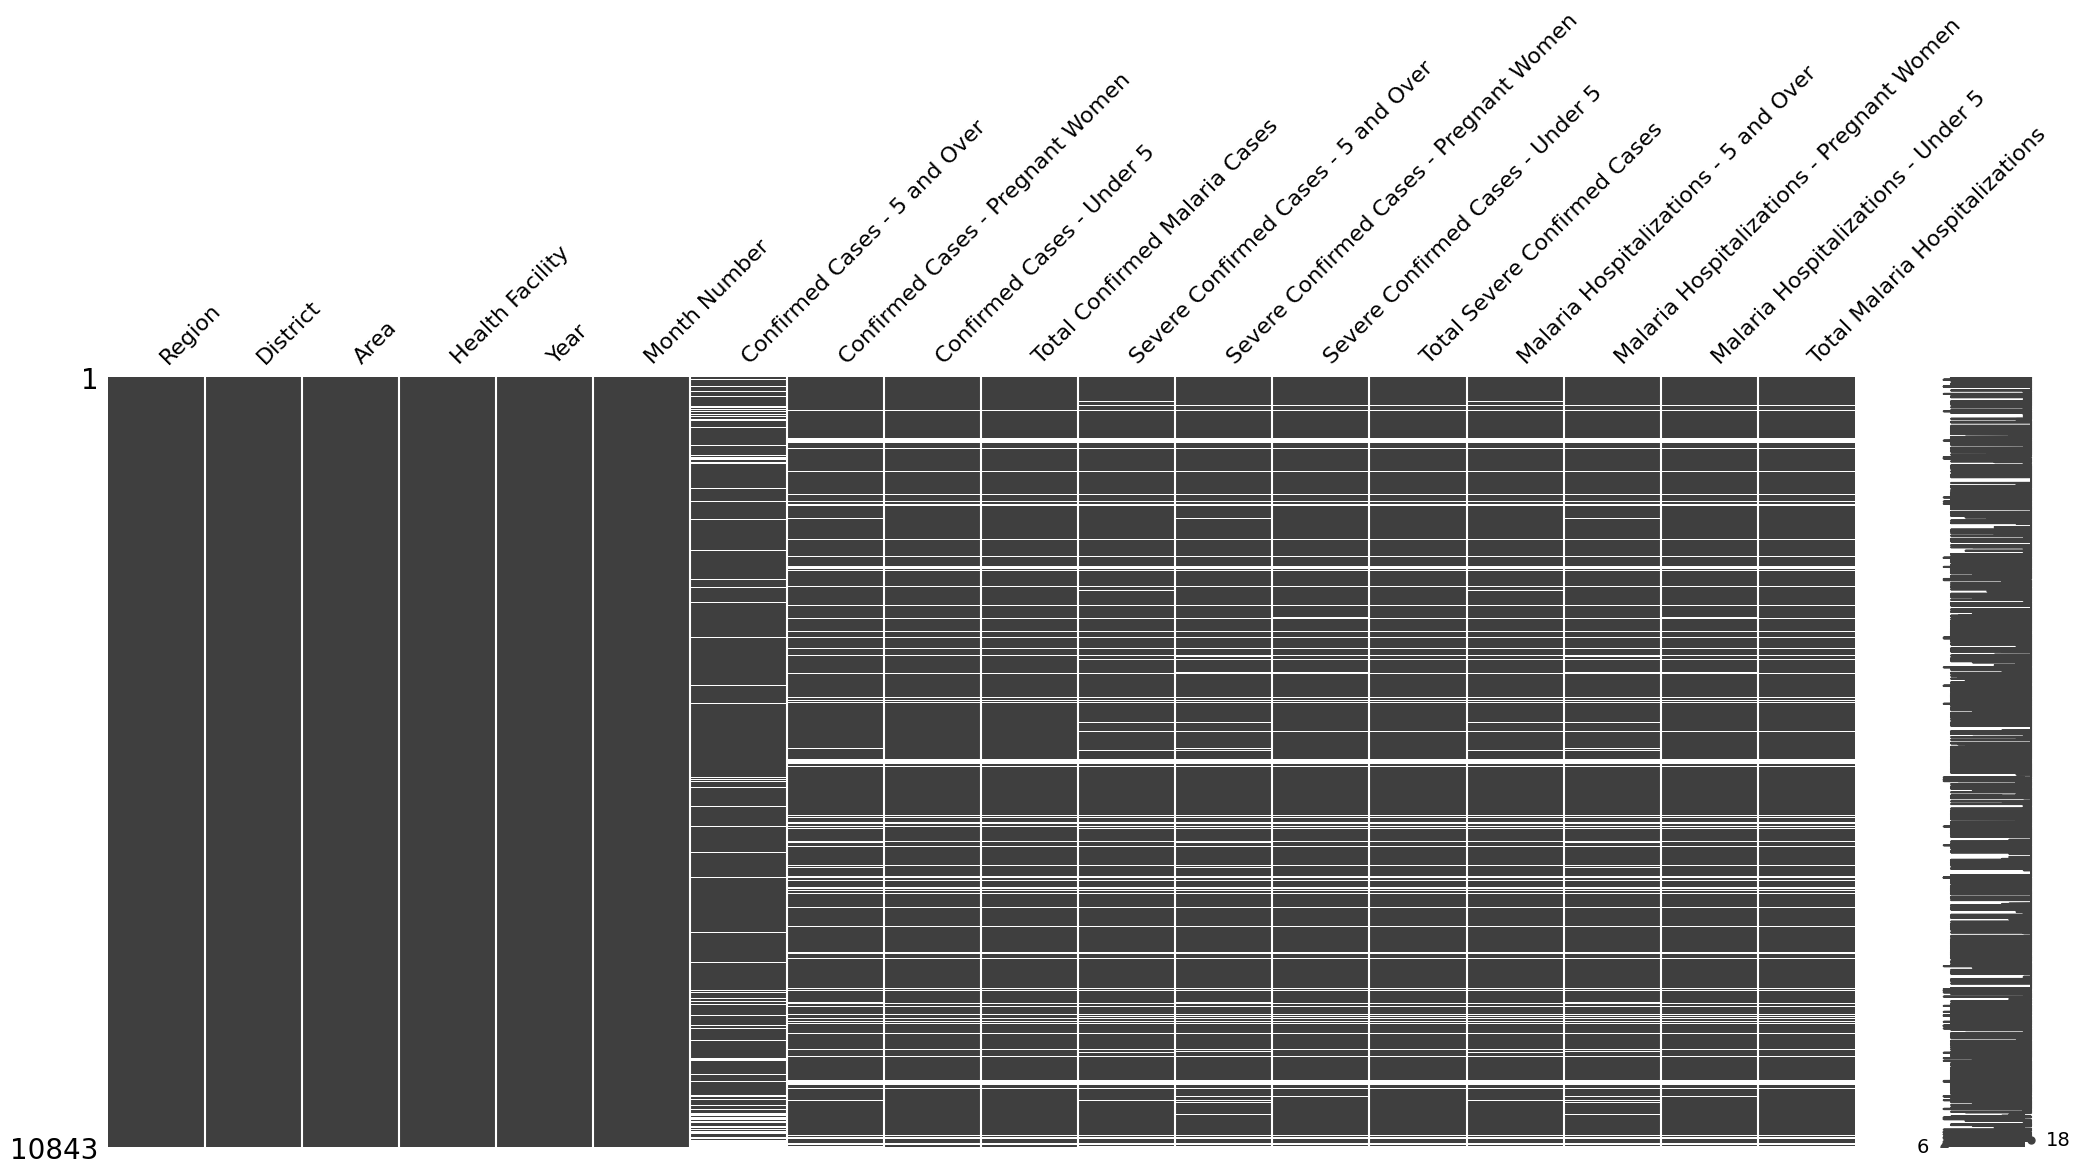

In [10]:
missingno.matrix(raw_data)

In [11]:
# raw_data.District.sort_values().unique()

In [12]:
raw_data = raw_data.set_axis(['GID0', 'GID2', 'GID3', 'Facility', 'Year', 'Month', 
                              'Case_OVR5', 'Case_PRGN', 'Case_UND5', 'Case_TOTAL', 
                              'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_UND5', 'Sevr_TOTAL', 
                              'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_UND5', 'Hosp_TOTAL', ], axis=1)

In [13]:
raw_data.head()

,GID0,GID2,GID3,Facility,Year,Month,Case_OVR5,Case_PRGN,Case_UND5,Case_TOTAL,Sevr_OVR5,Sevr_PRGN,Sevr_UND5,Sevr_TOTAL,Hosp_OVR5,Hosp_PRGN,Hosp_UND5,Hosp_TOTAL
0,Nord,District Gaschiga,AS Bascheo,CMA Bacheo (PSF),2025,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Extreme-Nord,District Mora,AS Kourgui,CMM 42� BIM (CMA militaire 42e bim),2025,1,0.0,16.0,160.0,331.0,50.0,4.0,50.0,104.0,50.0,4.0,50.0,104.0
2,Extreme-Nord,District Mokolo,AS Ouro Tada,(Closed) Clinique du Docteur Kollo Pierre,2025,1,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Extreme-Nord,District Maroua 1,AS Ouro Tchede,Cabinet de Sant� Djinavou de Marva,2025,1,6.0,1.0,1.0,5.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,Nord,District Garoua 2,AS Poumpoumre,Cabinet de soin le Bien �tre (Closed),2025,1,68.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
case_columns = ['Case_UND5', 'Case_OVR5', 'Case_PRGN', 'Case_TOTAL',
                'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL', 
                ]

In [15]:
raw_data.shape

(10843, 18)

In [16]:
raw_data.dropna(axis = 0, subset = case_columns, how = 'all', inplace = True)
raw_data.shape

(10730, 18)

<Axes: >

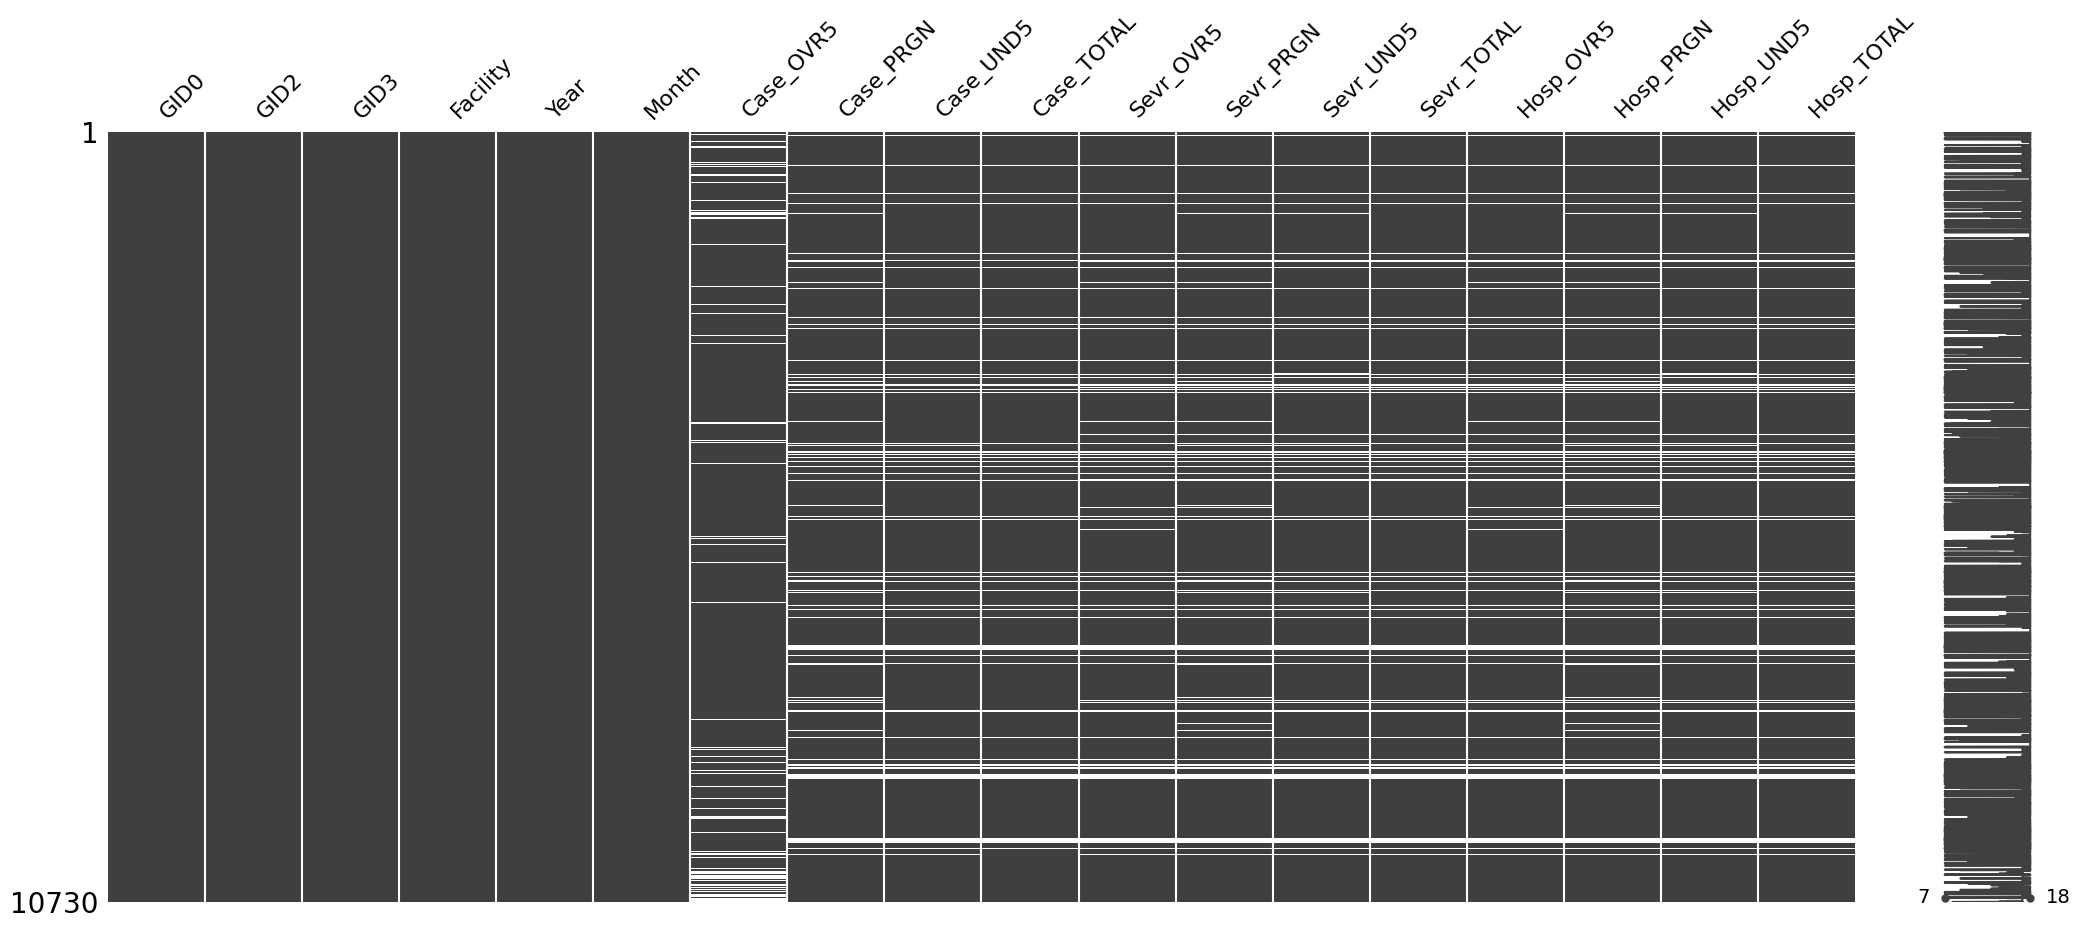

In [17]:
raw_data.reset_index(drop=True, inplace=True)
missingno.matrix(raw_data)

In [18]:
raw_data[case_columns] = raw_data[case_columns].astype('Int64') 


In [19]:
raw_data['dt_placement'] = pd.to_datetime(raw_data['Year'].astype(str) + '-' + raw_data['Month'].astype(str), format='%Y-%m')
raw_data['dt_placement'] = raw_data['dt_placement'].dt.strftime('%m-%Y')
raw_data['dt_placement'] = pd.to_datetime(raw_data['dt_placement'], errors='coerce').dt.to_period('M')
raw_data.head()

,GID0,GID2,GID3,Facility,Year,Month,Case_OVR5,Case_PRGN,Case_UND5,Case_TOTAL,Sevr_OVR5,Sevr_PRGN,Sevr_UND5,Sevr_TOTAL,Hosp_OVR5,Hosp_PRGN,Hosp_UND5,Hosp_TOTAL,dt_placement
0,Nord,District Gaschiga,AS Bascheo,CMA Bacheo (PSF),2025,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-01
1,Extreme-Nord,District Mora,AS Kourgui,CMM 42� BIM (CMA militaire 42e bim),2025,1,0,16,160,331,50,4,50,104,50,4,50,104,2025-01
2,Extreme-Nord,District Mokolo,AS Ouro Tada,(Closed) Clinique du Docteur Kollo Pierre,2025,1,19,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-01
3,Extreme-Nord,District Maroua 1,AS Ouro Tchede,Cabinet de Sant� Djinavou de Marva,2025,1,6,1,1,5,1,0,0,1,1,0,0,1,2025-01
4,Nord,District Garoua 2,AS Poumpoumre,Cabinet de soin le Bien �tre (Closed),2025,1,68,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-01


In [20]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10730 entries, 0 to 10729
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   GID0          10730 non-null  object   
 1   GID2          10730 non-null  object   
 2   GID3          10730 non-null  object   
 3   Facility      10730 non-null  object   
 4   Year          10730 non-null  int64    
 5   Month         10730 non-null  int64    
 6   Case_OVR5     9690 non-null   Int64    
 7   Case_PRGN     9543 non-null   Int64    
 8   Case_UND5     9669 non-null   Int64    
 9   Case_TOTAL    9699 non-null   Int64    
 10  Sevr_OVR5     9568 non-null   Int64    
 11  Sevr_PRGN     9419 non-null   Int64    
 12  Sevr_UND5     9543 non-null   Int64    
 13  Sevr_TOTAL    9612 non-null   Int64    
 14  Hosp_OVR5     9568 non-null   Int64    
 15  Hosp_PRGN     9419 non-null   Int64    
 16  Hosp_UND5     9543 non-null   Int64    
 17  Hosp_TOTAL    9612 non-null   I

In [21]:
raw_data['GID0'] = raw_data['GID0'].str.lower()
raw_data['GID2'] = raw_data['GID2'].str.lower()
raw_data['GID3'] = raw_data['GID3'].str.lower()
raw_data.drop(columns=['Facility'], inplace=True)

raw_data['GID2'] = raw_data['GID2'].str.replace(r'^district ', '', regex=True)
raw_data['GID3'] = raw_data['GID3'].str.replace(r'^as ', '', regex=True)

raw_data['GID0'] = raw_data['GID0'].str.replace("-", " ", regex=False)

In [22]:
raw_data.GID0.sort_values().unique()

array(['extreme nord', 'nord'], dtype=object)

In [23]:
raw_data.GID2.sort_values().unique()

array(['bibemi', 'bogo', 'bourha', 'figuil', 'fotokol', 'garoua 1',
       'garoua 2', 'gaschiga', 'gazawa', 'golombe', 'goulfey', 'guere',
       'guider', 'guidiguis', 'hina', 'kaele', 'kar hay', 'kolofata',
       'kousseri', 'koza', 'lagdo', 'mada', 'maga', 'makary', 'maroua 1',
       'maroua 2', 'maroua 3', 'mayo oulo', 'meri', 'mindif', 'mogode',
       'mokolo', 'mora', 'moulvoudaye', 'moutourwa', 'mozogo', 'ngong',
       'pette', 'pitoa', 'poli', 'rey bouba', 'roua', 'tchollire',
       'tokombere', 'touboro', 'vele', 'waza', 'yagoua'], dtype=object)

In [24]:
raw_data.GID3.sort_values().unique()

array([' as souari 2', 'adoumri', 'afade', 'aissa harde', 'alagarno',
       'alpha', 'amchedire', 'amchide', 'amchilga', 'amdjagara',
       'assighassia', 'babla', 'babouri', 'badadji', 'badang',
       'badankali', 'badjengo', 'badjouma centre', 'badjouma radier',
       'baikwa', 'bajaoul�', 'bakona', 'balaza', 'balda', 'balga',
       'balkossa', 'bame', 'banaye', 'bangana', 'bangli', 'bargaram',
       'barlang', 'barndake', 'bascheo', 'batao', 'be', 'begue palam',
       'beguele', 'beka', 'beka 2', 'belguede', 'beli', 'bere', 'bering',
       'biamo', 'bibemi', 'bide', 'bidzar', 'bimba (poli)', 'biou',
       'bipaing', 'birio', 'bissoli', 'bizili', 'blangoua', 'blaram',
       'boboyo', 'bocki', 'bockl�', 'bodo', 'bogo', 'bomboyo', 'borai',
       'bosgoye', 'bossoum', 'boudoum', 'bougaye', 'boukoula', 'boula',
       'boula ibib', 'boumba', 'boumedje', 'bounderi', 'bourha',
       'dabanga', 'dabaye', 'dadjamka', 'dagai (gazawa)', 'damai', 'dana',
       'darak', 'daram', 'da

In [25]:
raw_data['location'] = list(zip(raw_data['GID0'], raw_data['GID2'], raw_data['GID3']))

In [26]:
raw_data.head()

,GID0,GID2,GID3,Year,Month,Case_OVR5,Case_PRGN,Case_UND5,Case_TOTAL,Sevr_OVR5,Sevr_PRGN,Sevr_UND5,Sevr_TOTAL,Hosp_OVR5,Hosp_PRGN,Hosp_UND5,Hosp_TOTAL,dt_placement,location
0,nord,gaschiga,bascheo,2025,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-01,"(nord, gaschiga, bascheo)"
1,extreme nord,mora,kourgui,2025,1,0,16,160,331,50,4,50,104,50,4,50,104,2025-01,"(extreme nord, mora, kourgui)"
2,extreme nord,mokolo,ouro tada,2025,1,19,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-01,"(extreme nord, mokolo, ouro tada)"
3,extreme nord,maroua 1,ouro tchede,2025,1,6,1,1,5,1,0,0,1,1,0,0,1,2025-01,"(extreme nord, maroua 1, ouro tchede)"
4,nord,garoua 2,poumpoumre,2025,1,68,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-01,"(nord, garoua 2, poumpoumre)"


In [27]:
cols_rearranged = ['location', 'dt_placement'] + case_columns

In [28]:
raw_data = raw_data[cols_rearranged]

In [29]:
raw_data.head()

,location,dt_placement,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL
0,"(nord, gaschiga, bascheo)",2025-01,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,"(extreme nord, mora, kourgui)",2025-01,160,0,16,331,50,50,4,104,50,50,4,104
2,"(extreme nord, mokolo, ouro tada)",2025-01,<NA>,19,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,"(extreme nord, maroua 1, ouro tchede)",2025-01,1,6,1,5,0,1,0,1,0,1,0,1
4,"(nord, garoua 2, poumpoumre)",2025-01,<NA>,68,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [30]:
pair_counts = raw_data.groupby(['location', 'dt_placement']).size().reset_index(name='count')
pair_counts['count'].max()

14

In [31]:
summed_data = raw_data.groupby(['location', 'dt_placement']).sum().reset_index()
summed_data.sort_values(by=['dt_placement', 'location'], inplace=True)
summed_data.reset_index(drop=True, inplace=True)
summed_data.head()

,location,dt_placement,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL
0,"(extreme nord, bogo, balaza)",2025-01,117,125,14,237,21,25,2,48,21,25,2,48
1,"(extreme nord, bogo, balda)",2025-01,77,56,12,139,20,11,8,39,20,11,8,39
2,"(extreme nord, bogo, bogo)",2025-01,179,42,59,432,67,63,42,172,67,63,42,172
3,"(extreme nord, bogo, borai)",2025-01,65,40,2,144,26,27,0,53,26,27,0,53
4,"(extreme nord, bogo, guinggley)",2025-01,104,0,23,173,32,9,9,50,32,9,9,50


In [32]:
pair_counts_summed = summed_data.groupby(['location', 'dt_placement']).size().reset_index(name='count')
pair_counts_summed['count'].max()

1

In [33]:
for col in case_columns:
    print(f"Total {col}: {raw_data[col].sum():,}")

Total Case_UND5: 350,378
Total Case_OVR5: 384,153
Total Case_PRGN: 62,063
Total Case_TOTAL: 796,663
Total Sevr_UND5: 80,140
Total Sevr_OVR5: 83,888
Total Sevr_PRGN: 28,995
Total Sevr_TOTAL: 193,023
Total Hosp_UND5: 80,140
Total Hosp_OVR5: 83,888
Total Hosp_PRGN: 28,995
Total Hosp_TOTAL: 193,023


In [34]:
for col in case_columns:
    print(f"Total {col}: {summed_data[col].sum():,}")

Total Case_UND5: 350,378
Total Case_OVR5: 384,153
Total Case_PRGN: 62,063
Total Case_TOTAL: 796,663
Total Sevr_UND5: 80,140
Total Sevr_OVR5: 83,888
Total Sevr_PRGN: 28,995
Total Sevr_TOTAL: 193,023
Total Hosp_UND5: 80,140
Total Hosp_OVR5: 83,888
Total Hosp_PRGN: 28,995
Total Hosp_TOTAL: 193,023


In [35]:
raw_data.shape

(10730, 14)

In [36]:
summed_data.shape

(6338, 14)

<Axes: >

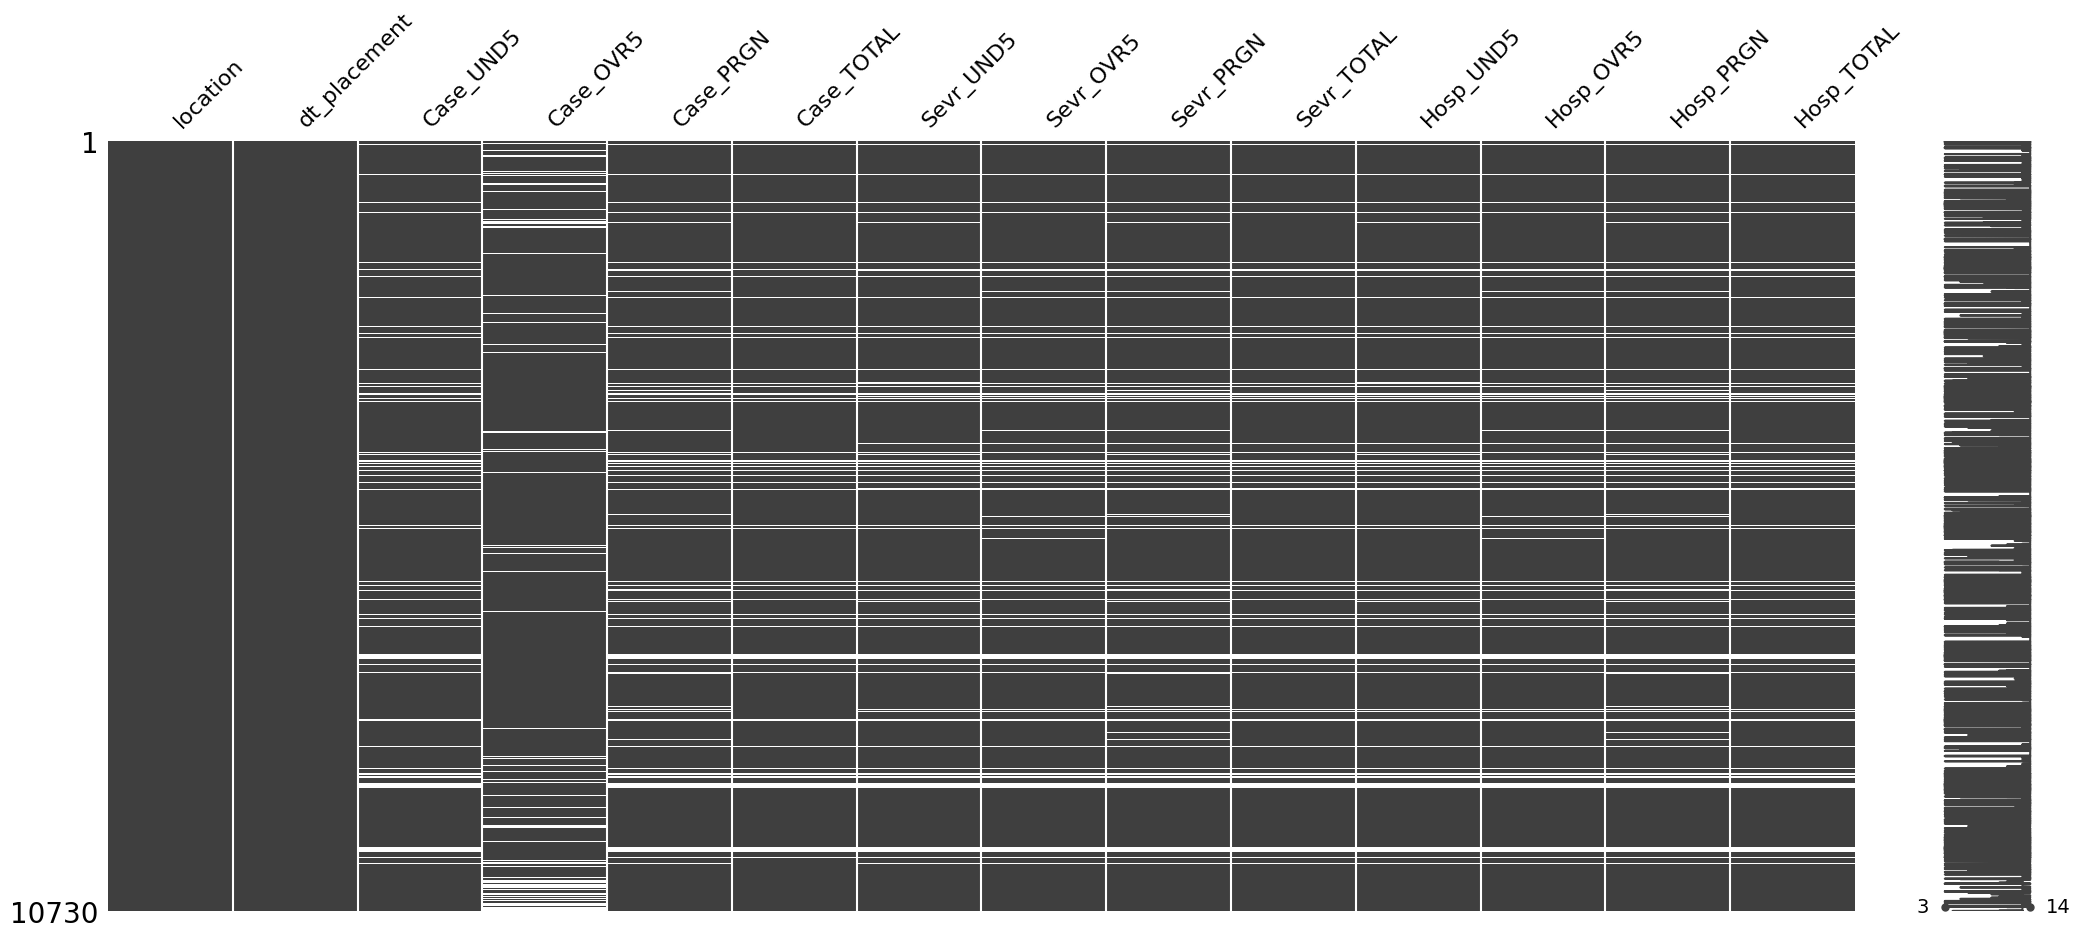

In [37]:
raw_data.reset_index(drop=True, inplace=True)
missingno.matrix(raw_data)

<Axes: >

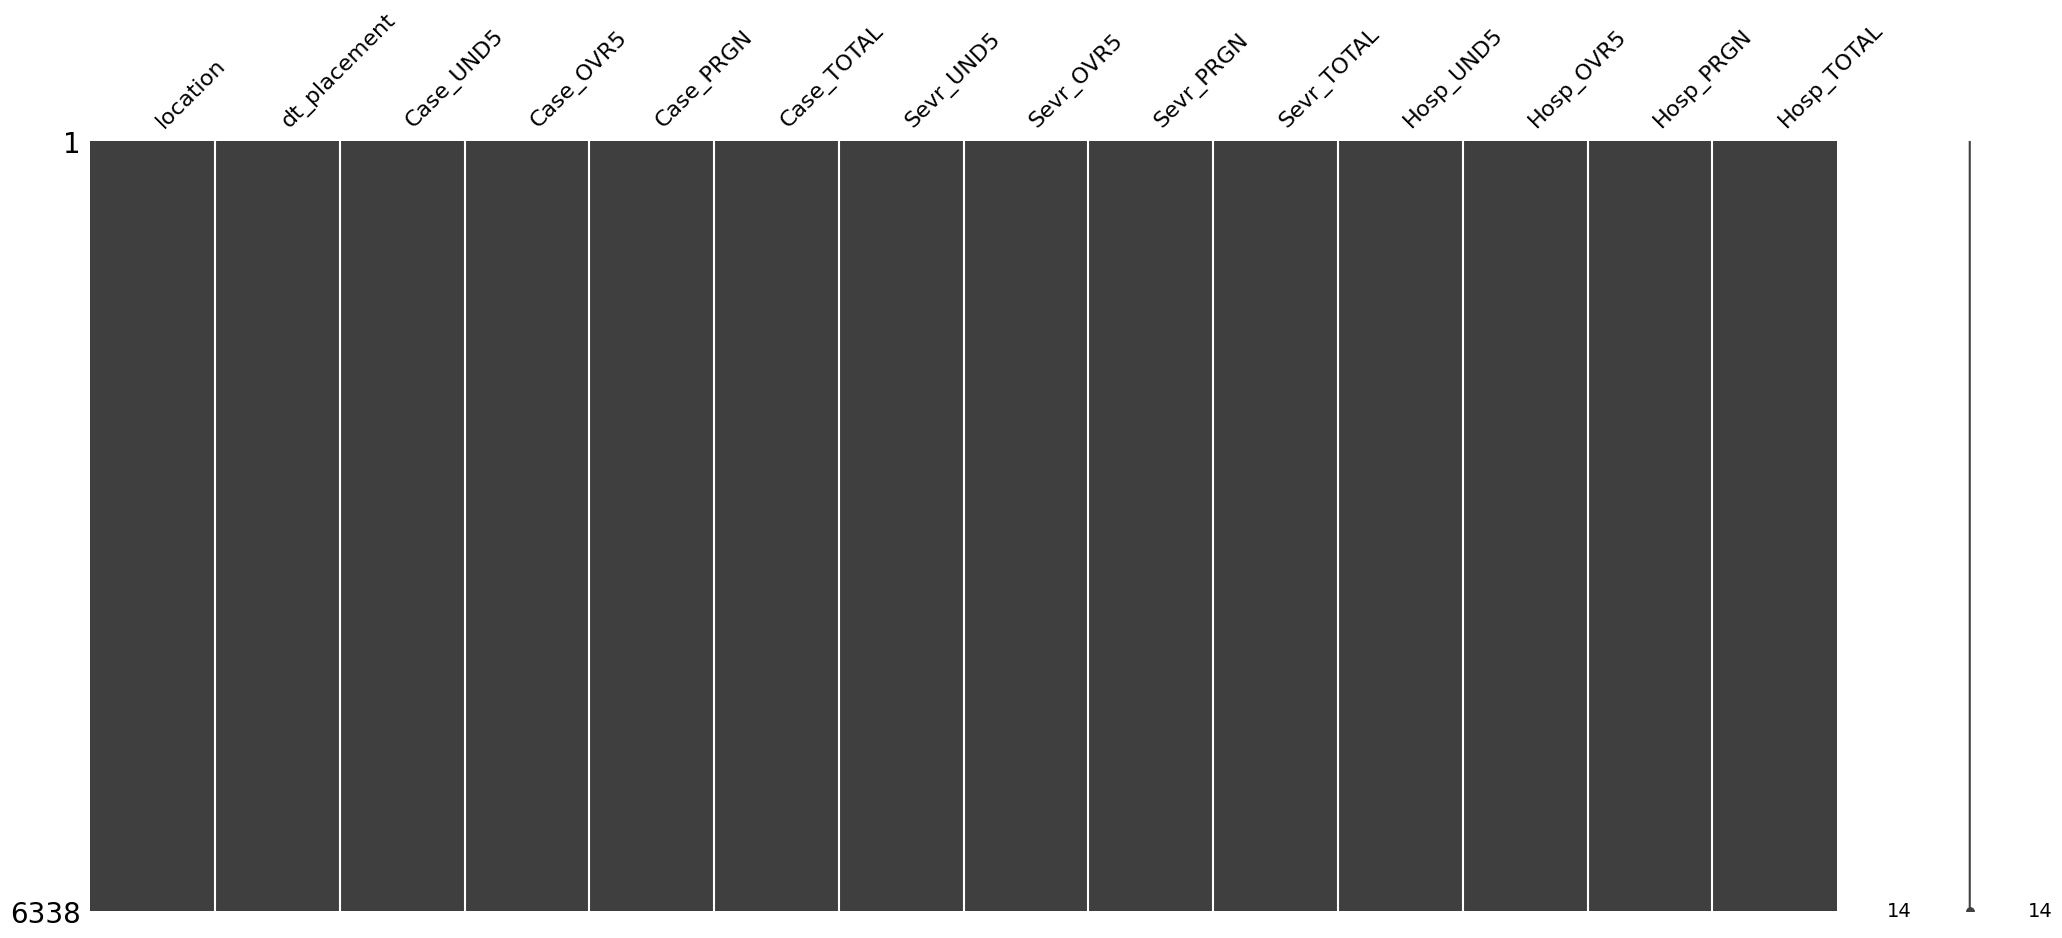

In [38]:
summed_data.reset_index(drop=True, inplace=True)
missingno.matrix(summed_data)

In [39]:
summed_data[['GID0', 'GID2', 'GID3']] = pd.DataFrame(summed_data['location'].tolist(), index=summed_data.index)
summed_data.drop(columns=['location'], inplace=True)

In [40]:
cols_rearranged = ['GID0', 'GID2', 'GID3', 'dt_placement'] + case_columns
summed_data = summed_data[cols_rearranged]

In [41]:
summed_data

,GID0,GID2,GID3,dt_placement,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL
0,extreme nord,bogo,balaza,2025-01,117,125,14,237,21,25,2,48,21,25,2,48
1,extreme nord,bogo,balda,2025-01,77,56,12,139,20,11,8,39,20,11,8,39
2,extreme nord,bogo,bogo,2025-01,179,42,59,432,67,63,42,172,67,63,42,172
3,extreme nord,bogo,borai,2025-01,65,40,2,144,26,27,0,53,26,27,0,53
4,extreme nord,bogo,guinggley,2025-01,104,0,23,173,32,9,9,50,32,9,9,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6333,nord,touboro,mbeing,2025-12,102,0,9,167,18,13,0,31,18,13,0,31
6334,nord,touboro,ngay lara,2025-12,132,33,78,334,79,63,48,190,79,63,48,190
6335,nord,touboro,touboro,2025-12,382,96,79,918,167,214,47,428,167,214,47,428
6336,nord,touboro,vogzom,2025-12,129,5,65,374,44,71,27,142,44,71,27,142


In [42]:
summed_data.to_csv('../data/CM_MAL_cases_GID2_2025_processed.csv', index=False, encoding = enc)

In [43]:
summed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6338 entries, 0 to 6337
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   GID0          6338 non-null   object   
 1   GID2          6338 non-null   object   
 2   GID3          6338 non-null   object   
 3   dt_placement  6338 non-null   period[M]
 4   Case_UND5     6338 non-null   Int64    
 5   Case_OVR5     6338 non-null   Int64    
 6   Case_PRGN     6338 non-null   Int64    
 7   Case_TOTAL    6338 non-null   Int64    
 8   Sevr_UND5     6338 non-null   Int64    
 9   Sevr_OVR5     6338 non-null   Int64    
 10  Sevr_PRGN     6338 non-null   Int64    
 11  Sevr_TOTAL    6338 non-null   Int64    
 12  Hosp_UND5     6338 non-null   Int64    
 13  Hosp_OVR5     6338 non-null   Int64    
 14  Hosp_PRGN     6338 non-null   Int64    
 15  Hosp_TOTAL    6338 non-null   Int64    
dtypes: Int64(12), object(3), period[M](1)
memory usage: 866.7+ KB


In [44]:
summed_data['Year'] = summed_data['dt_placement'].dt.year
summed_data['Month'] = summed_data['dt_placement'].dt.month

In [46]:
df_hospitalizations = summed_data[['GID0', 'GID2', 'GID3', 'Year', 'Month', 'dt_placement', 
                                'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL']].copy()

df_severe = summed_data[['GID0', 'GID2', 'GID3', 'Year', 'Month', 'dt_placement', 
                                'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL']].copy()

df_cases = summed_data[['GID0', 'GID2', 'GID3', 'Year', 'Month', 'dt_placement', 
                                'Case_UND5', 'Case_OVR5', 'Case_PRGN', 'Case_TOTAL']].copy()

<Axes: >

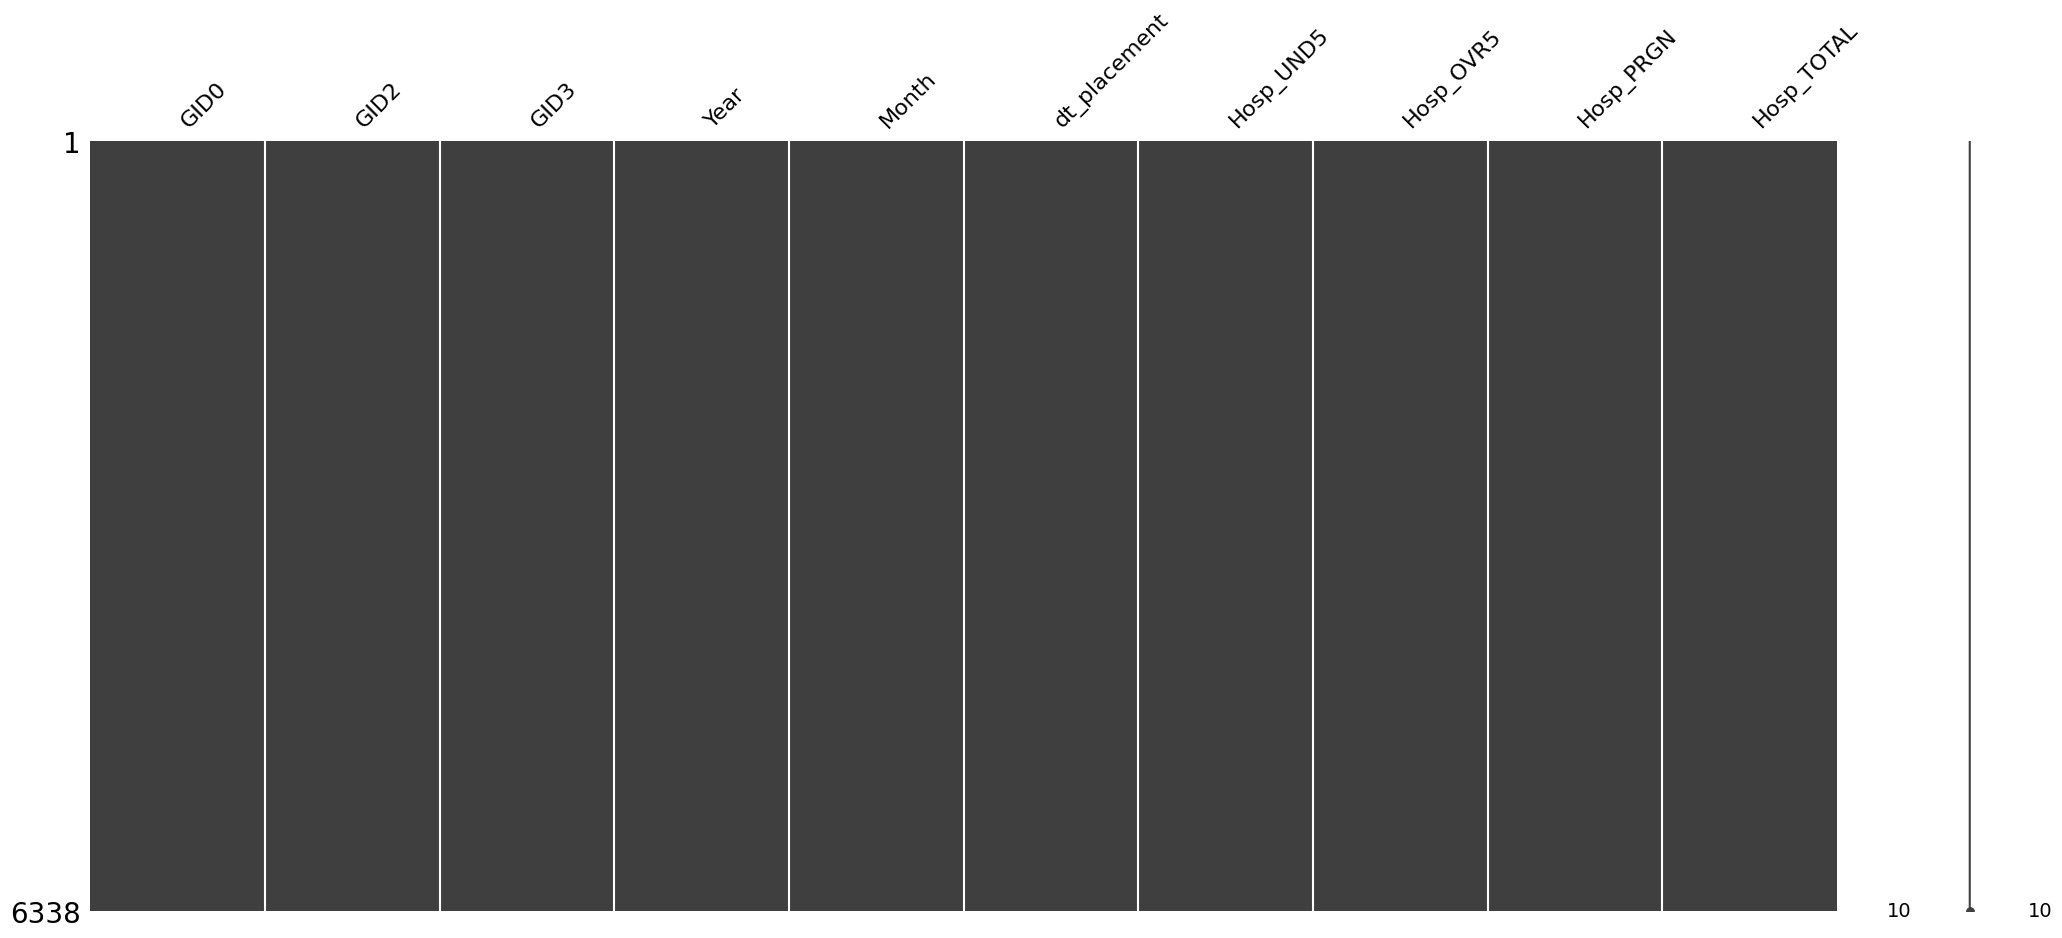

In [47]:
missingno.matrix(df_hospitalizations)

<Axes: >

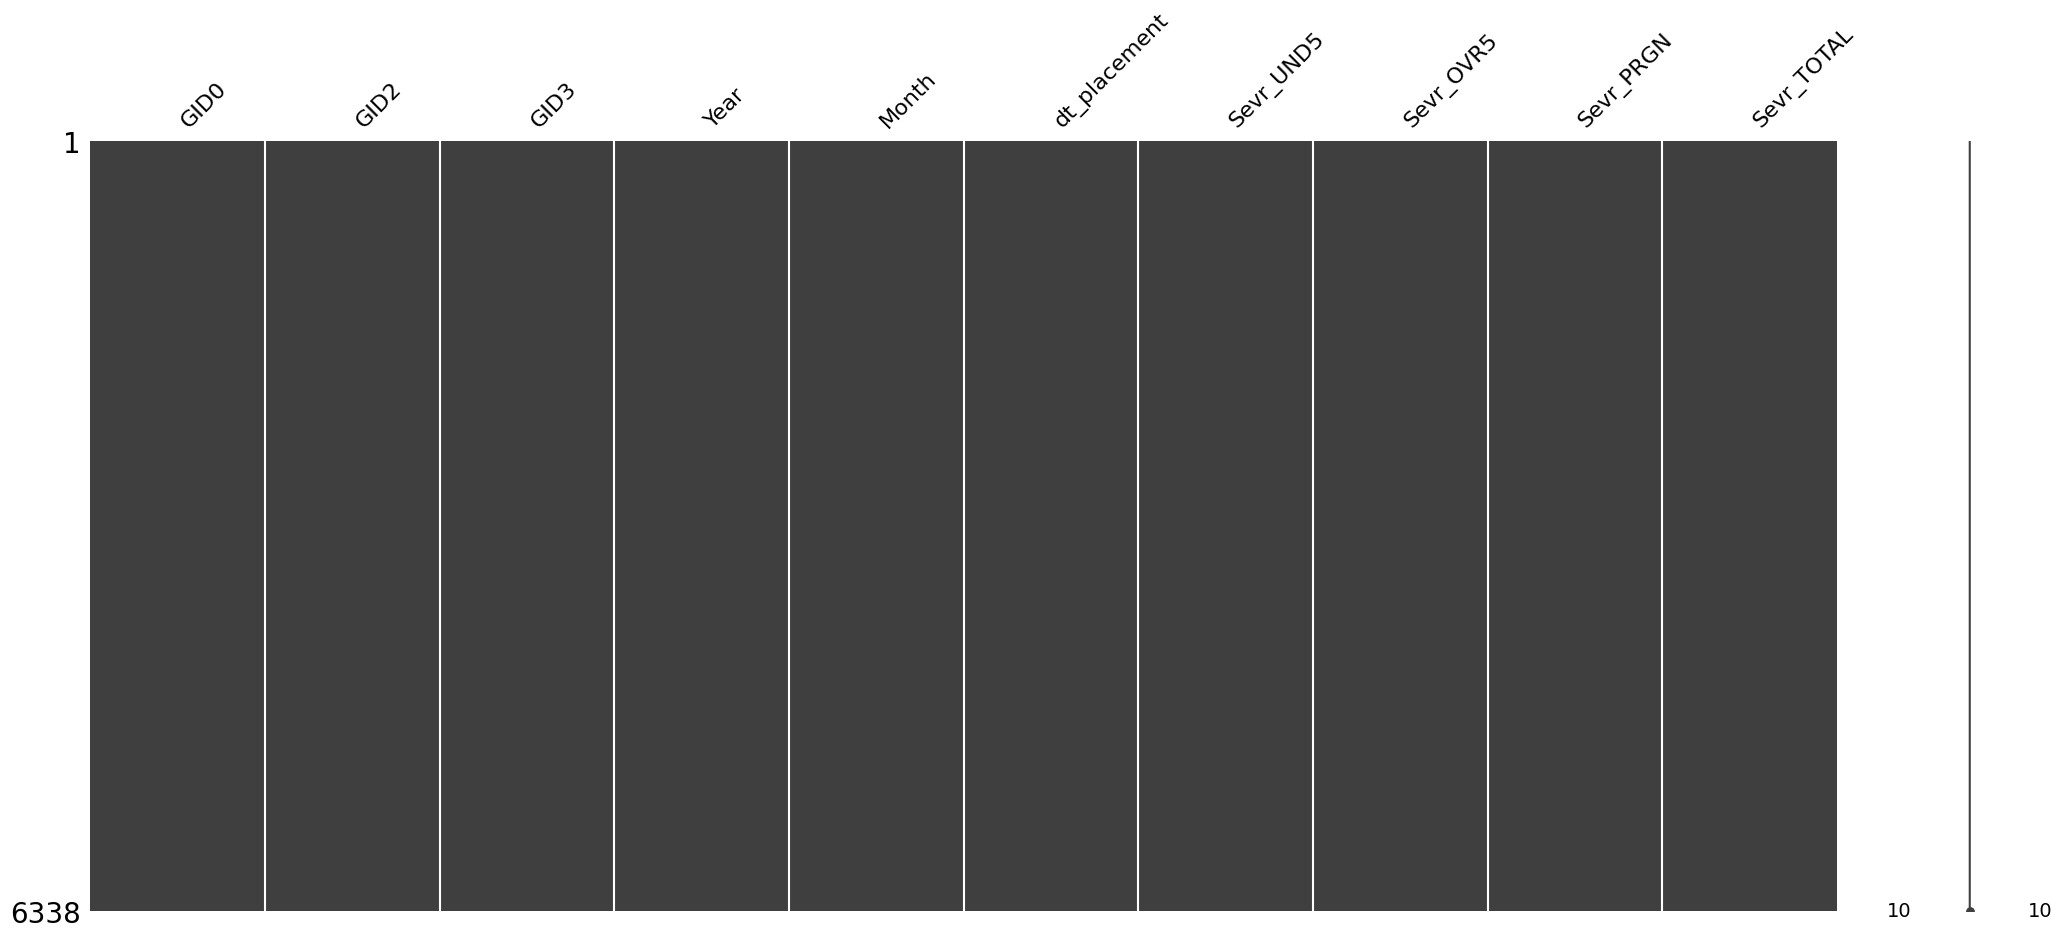

In [48]:
missingno.matrix(df_severe)

<Axes: >

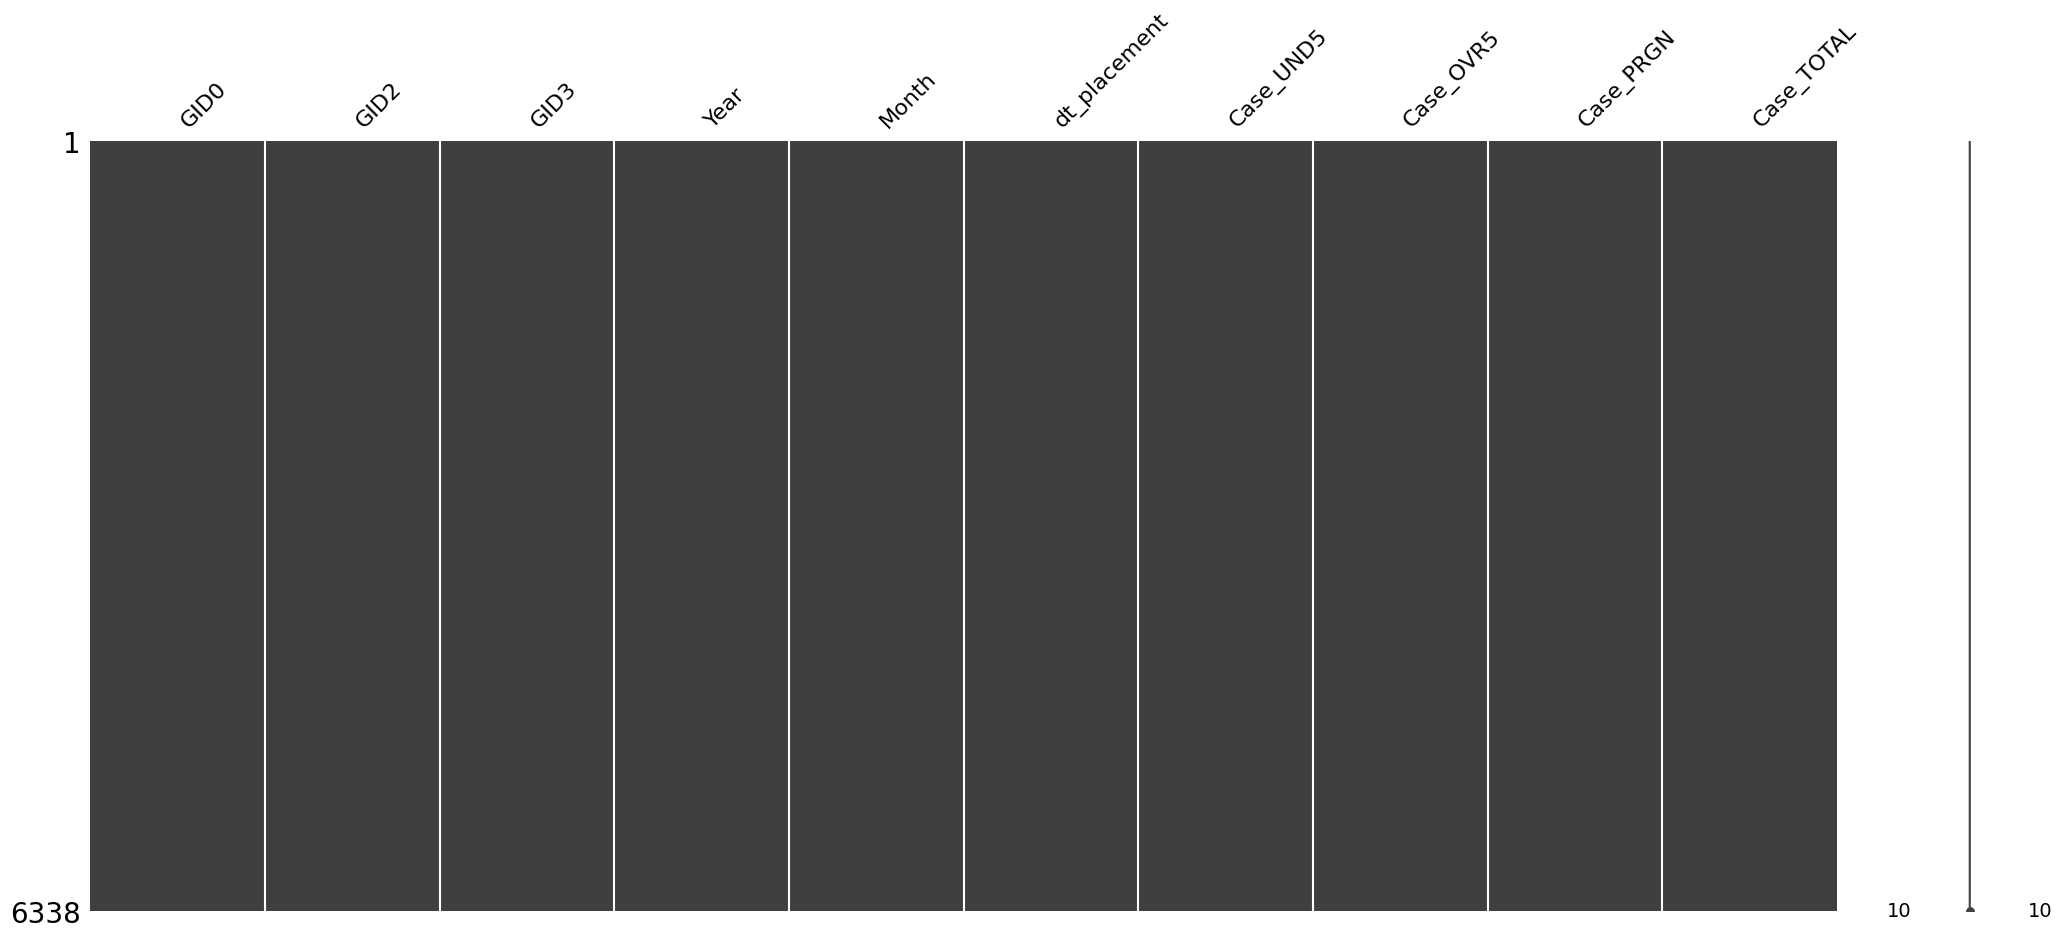

In [50]:
missingno.matrix(df_cases)

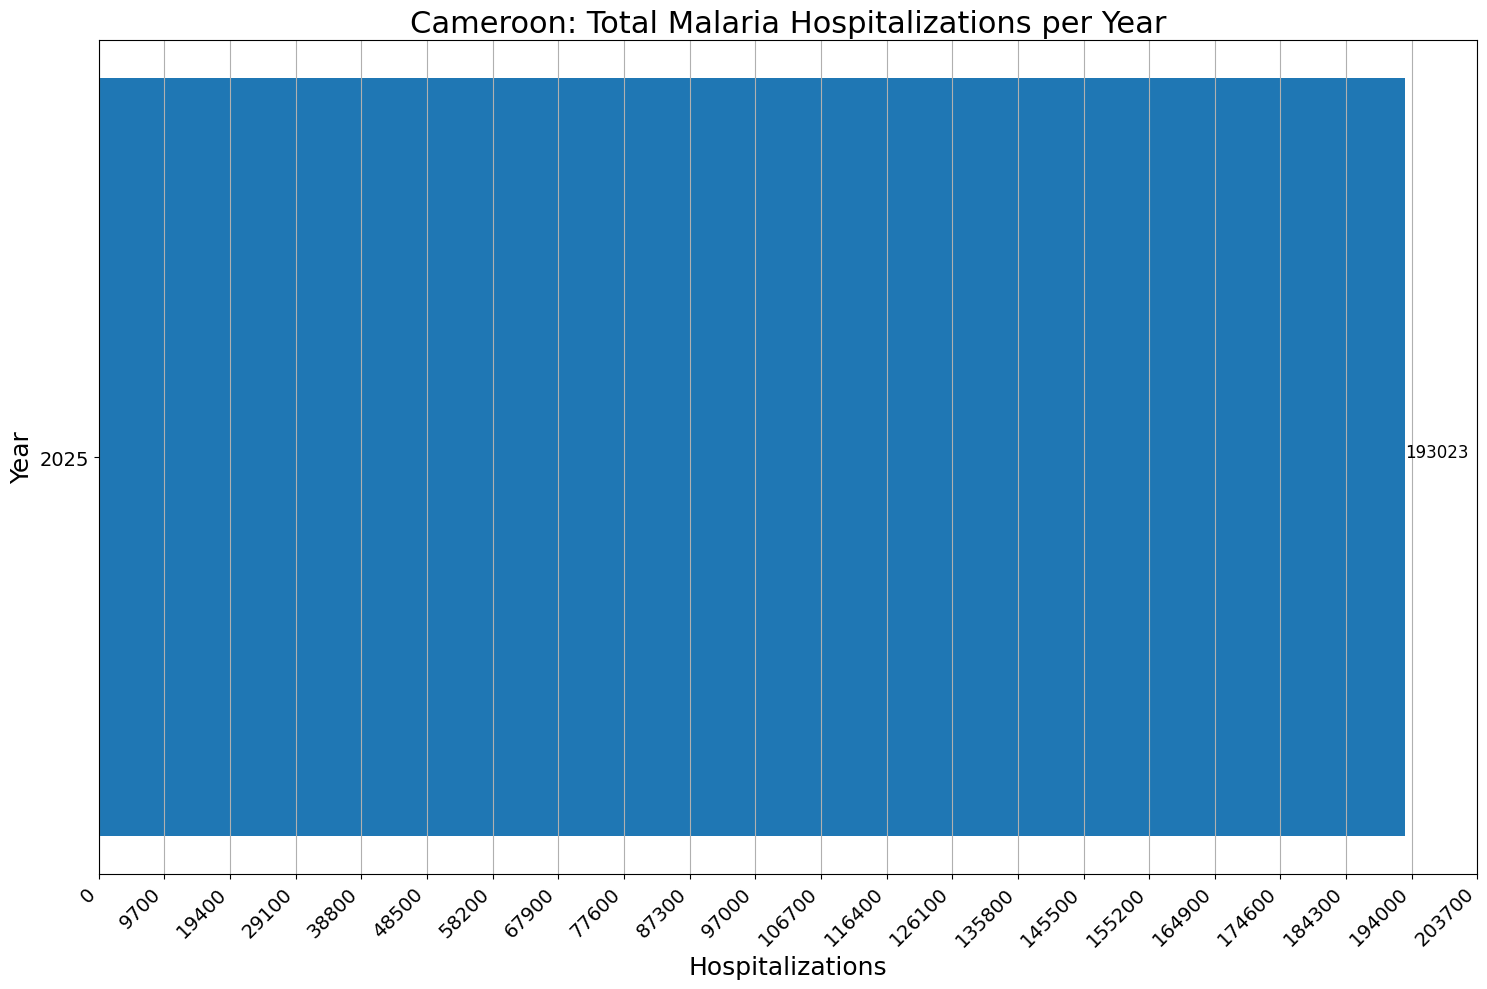

In [51]:
plot_grouped_barh(summed_data, group_col='Year', value_col='Hosp_TOTAL',
                  xlabel='Hospitalizations', ylabel='Year', title='Cameroon: Total Malaria Hospitalizations per Year')

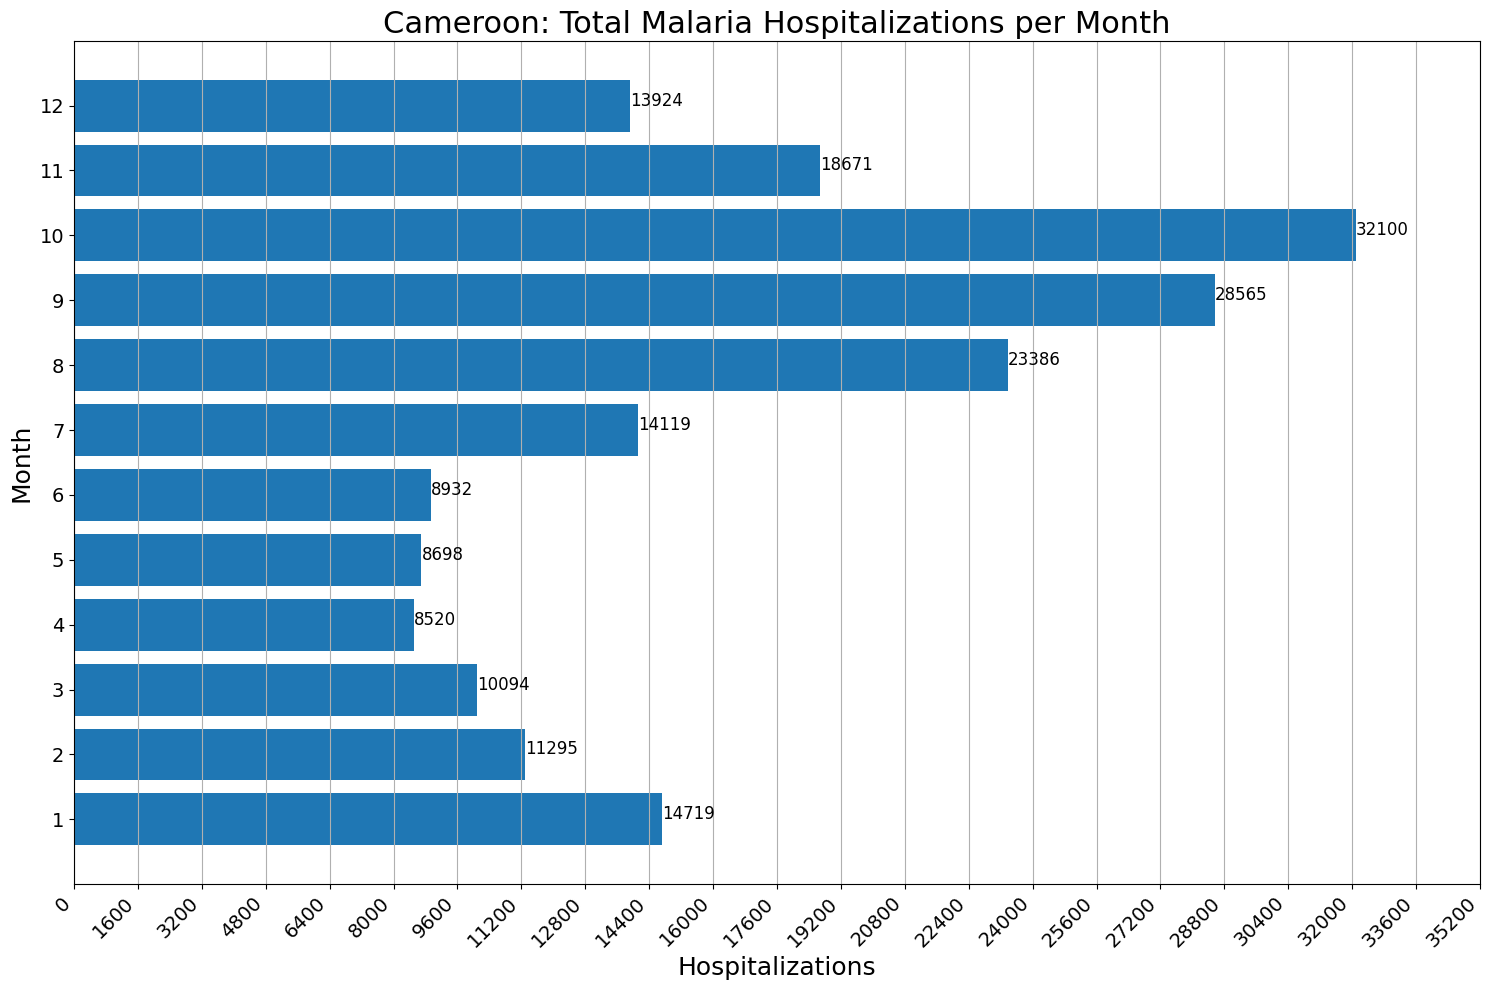

In [52]:
plot_grouped_barh(summed_data, group_col='Month', value_col='Hosp_TOTAL',
                  xlabel='Hospitalizations', ylabel='Month', title='Cameroon: Total Malaria Hospitalizations per Month')

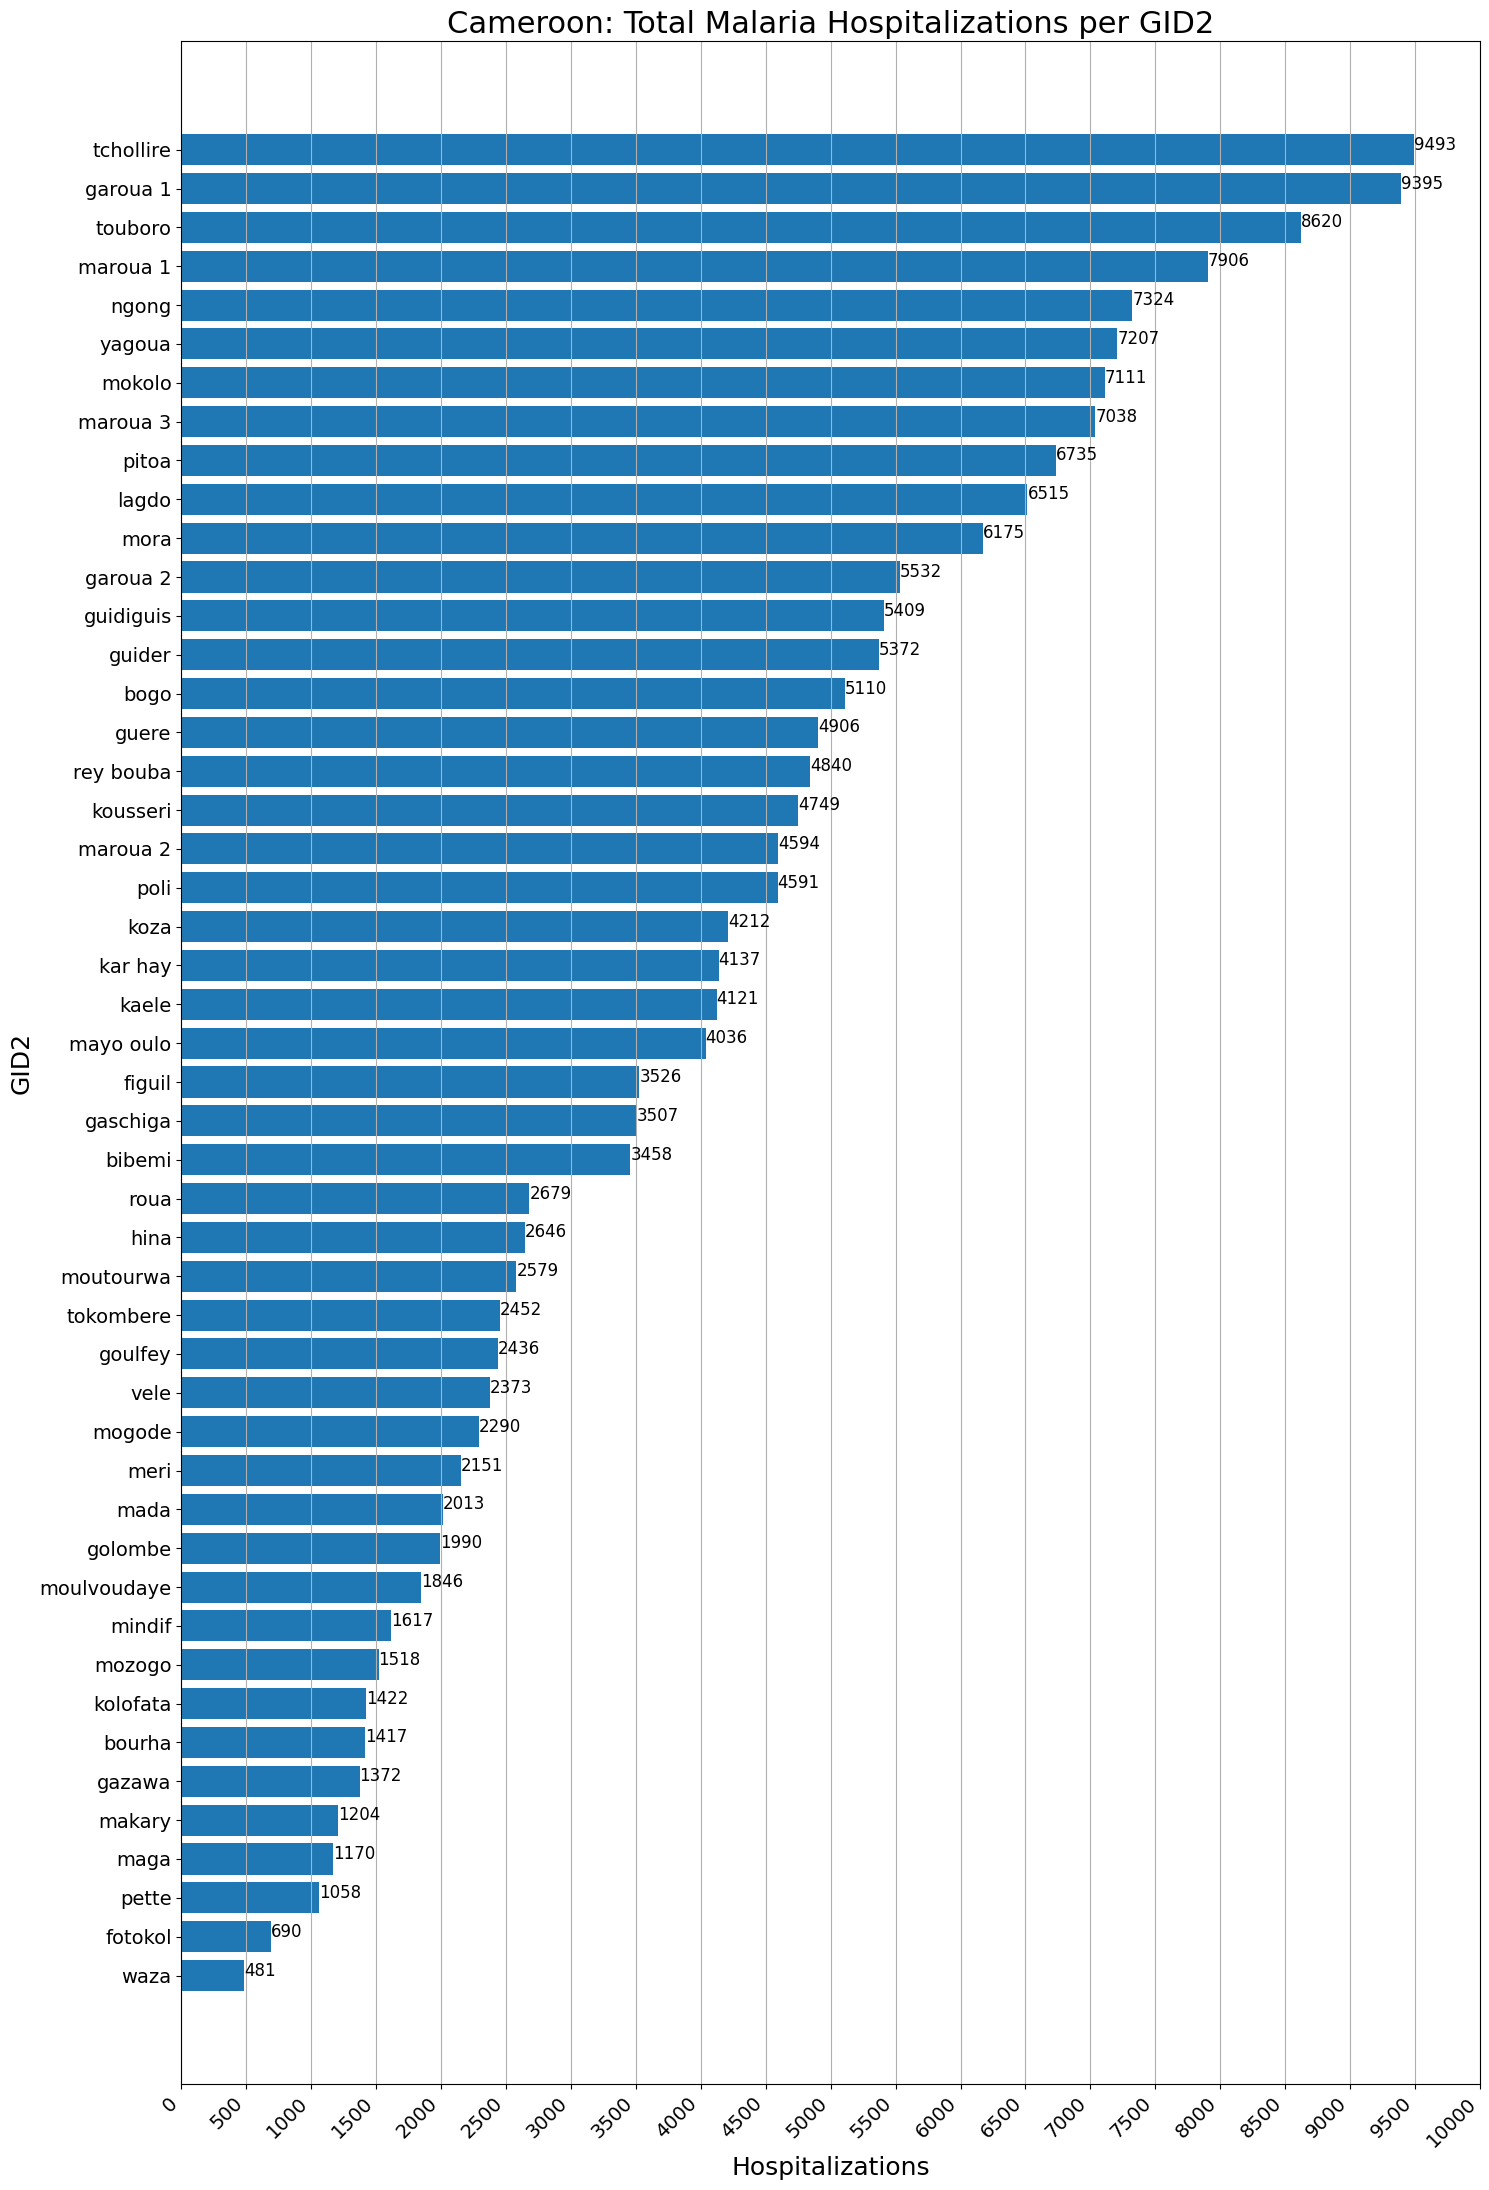

In [53]:
plot_grouped_barh(summed_data, group_col='GID2', value_col='Hosp_TOTAL',
                  xlabel='Hospitalizations', ylabel='GID2', title='Cameroon: Total Malaria Hospitalizations per GID2',
                  figsize=(15,22), text_size=12)

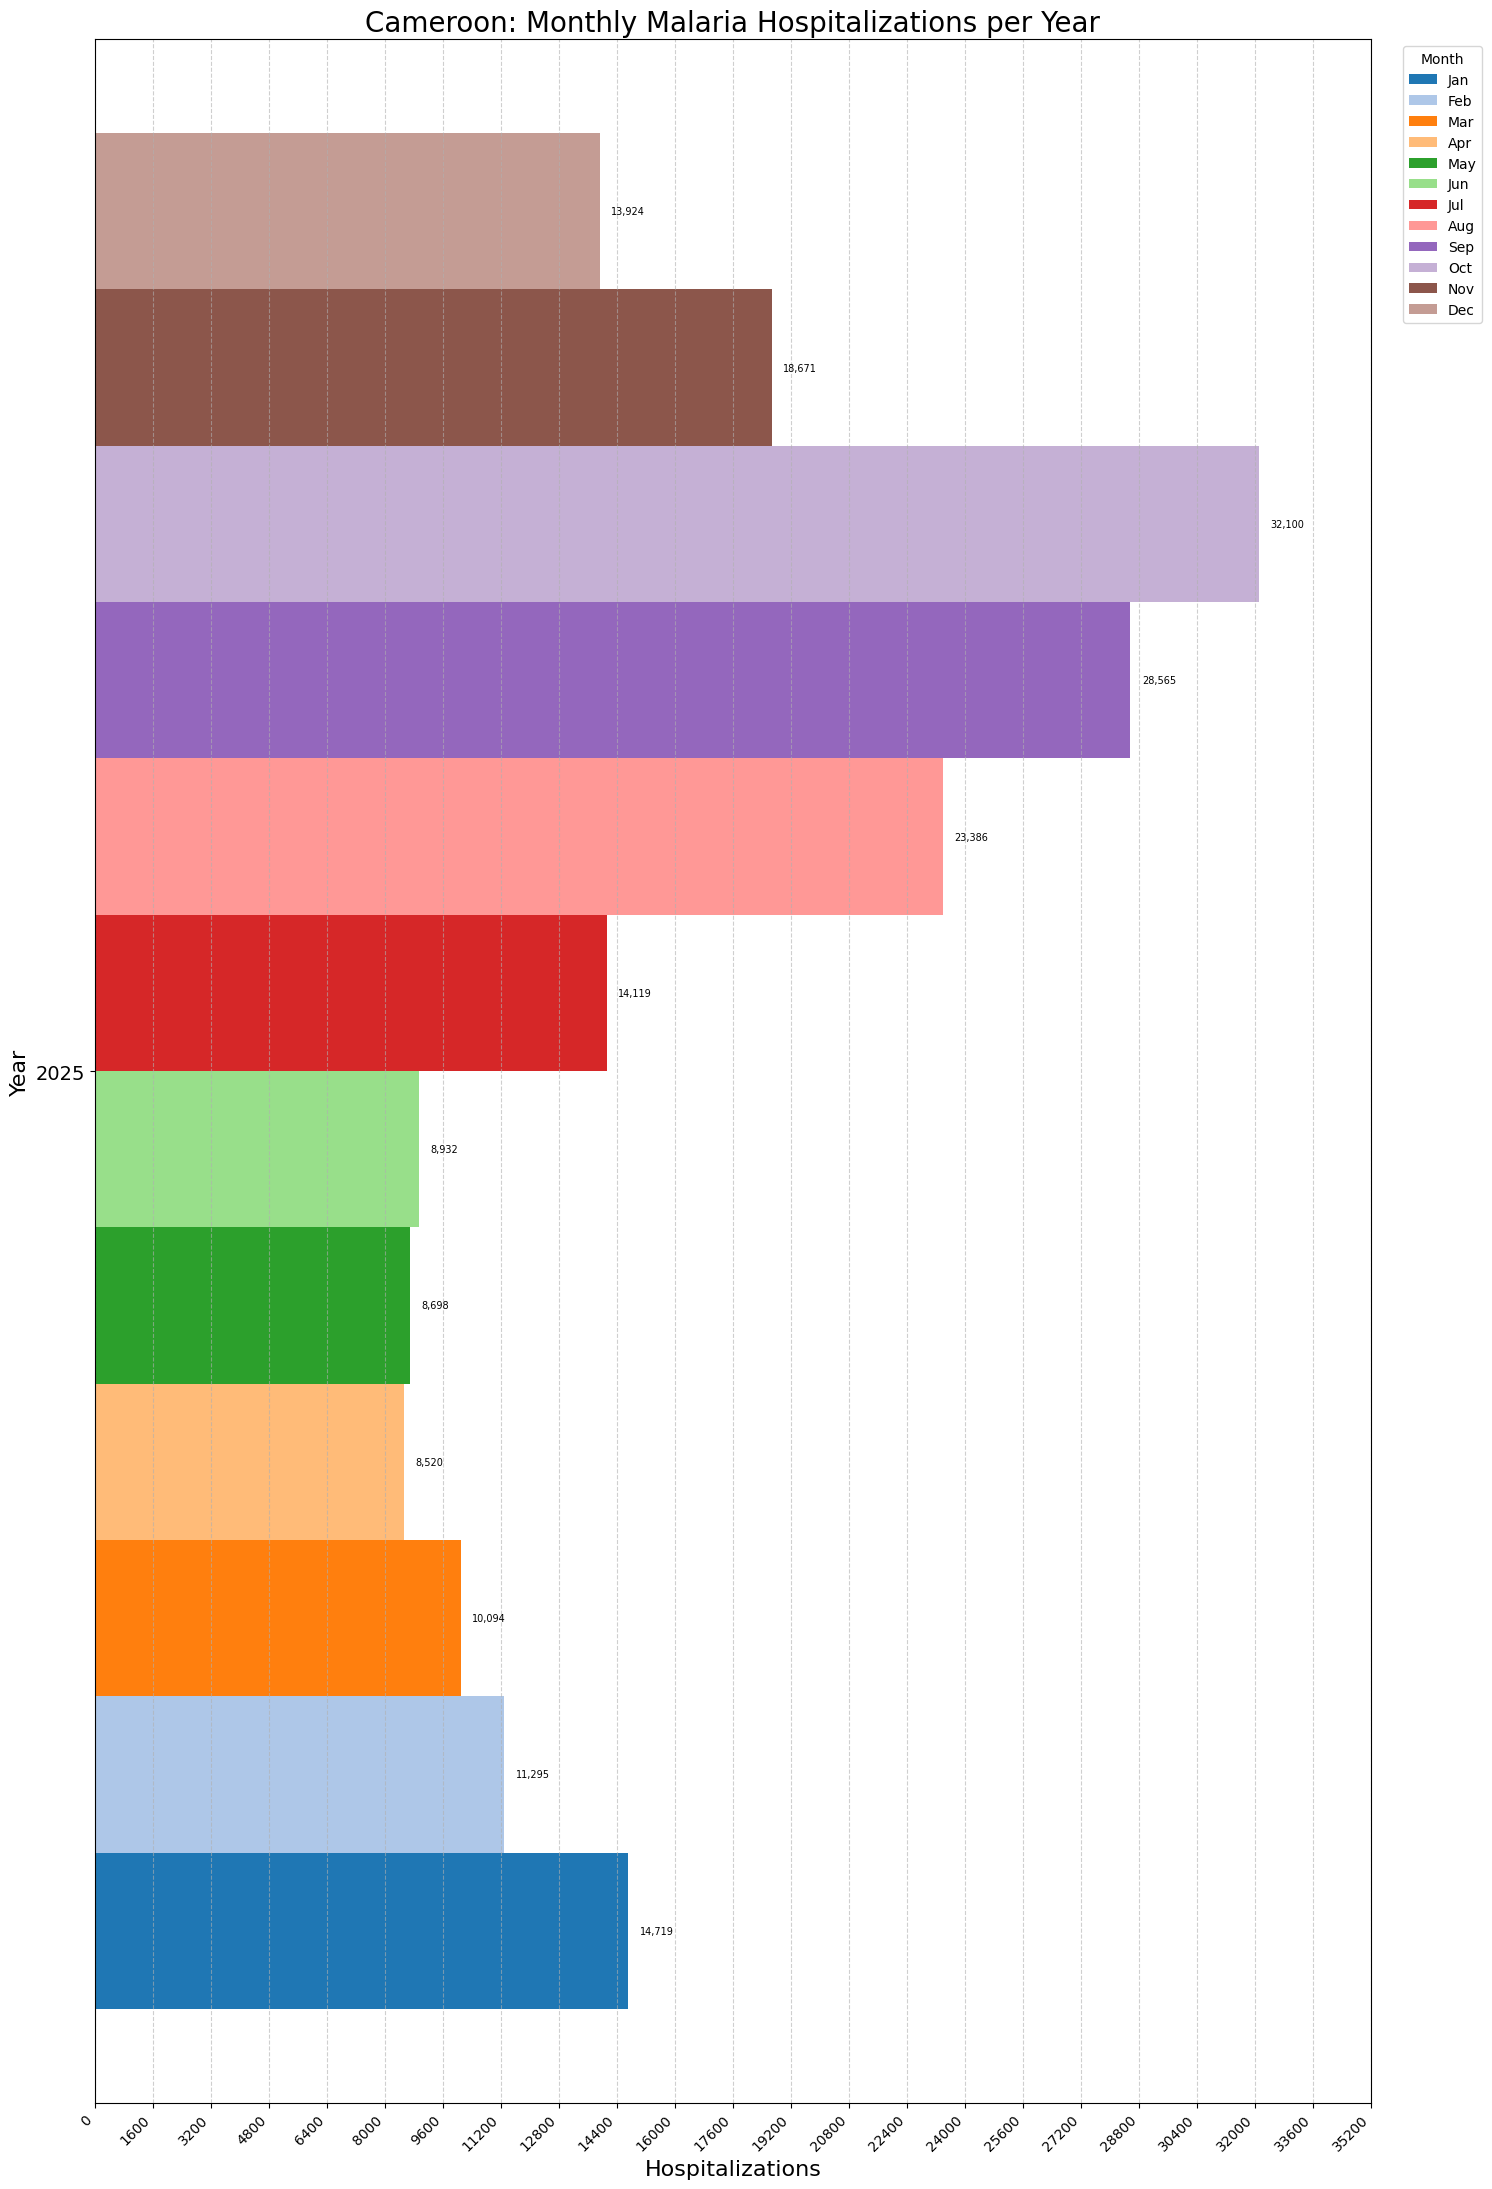

In [54]:
plot_monthly_yearly_horizontal_bars(summed_data, 'Hosp_TOTAL', bar_height_scale = 1.5, spacing_factor = 1.65, figsize=(15, 22),
                                    title='Cameroon: Monthly Malaria Hospitalizations per Year', xlabel='Hospitalizations')

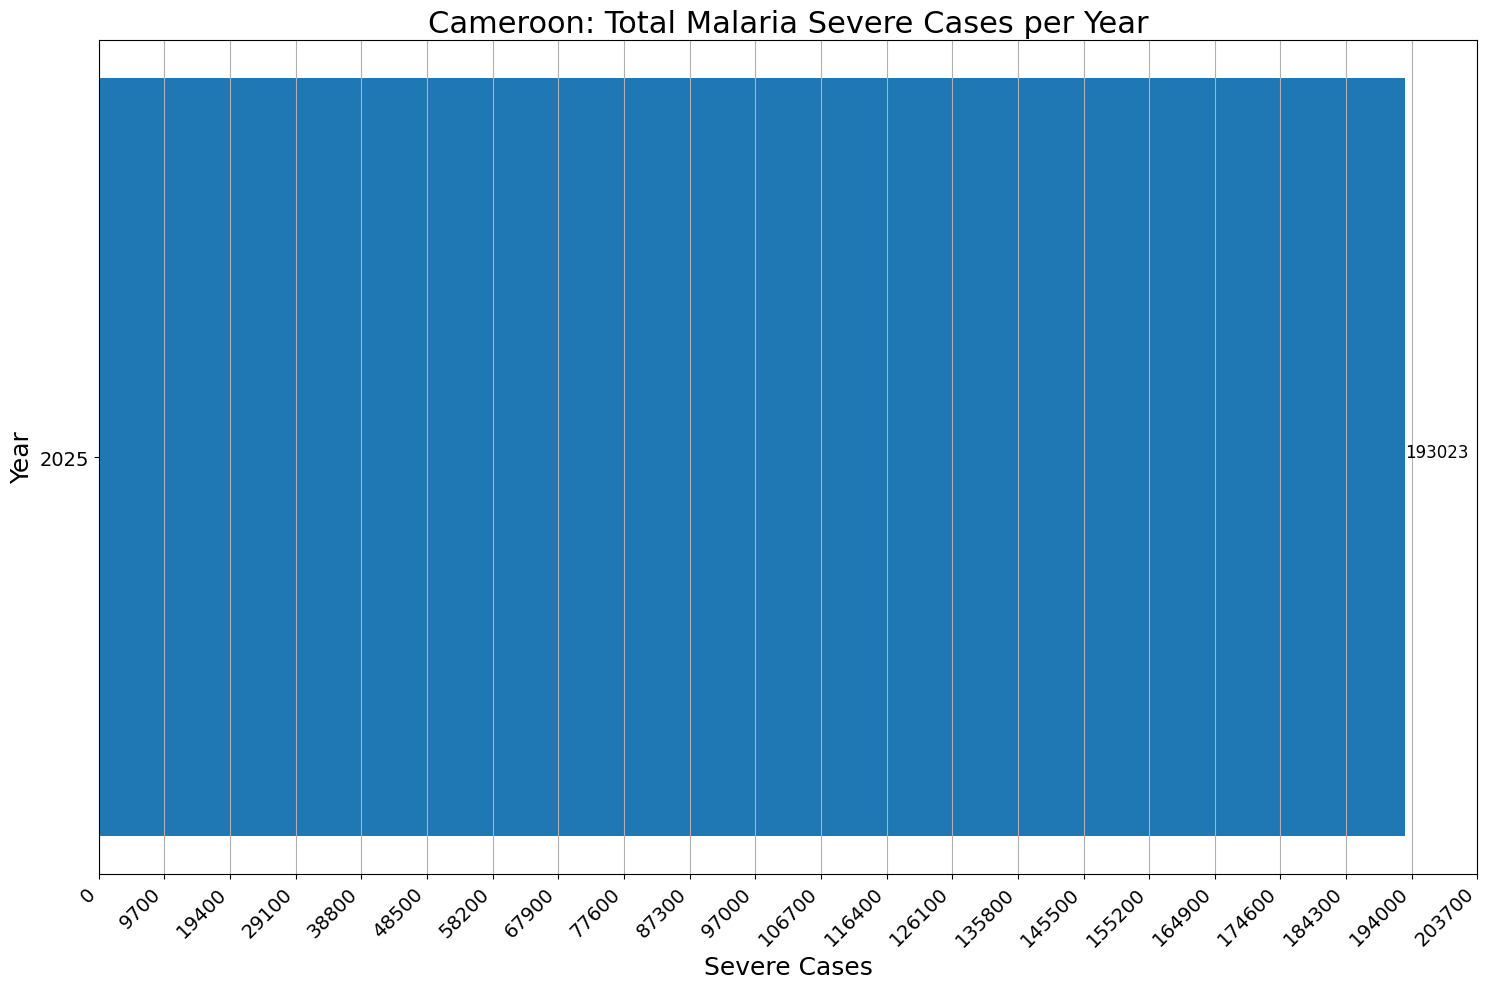

In [55]:
plot_grouped_barh(summed_data, group_col='Year', value_col='Sevr_TOTAL',
                  xlabel='Severe Cases', ylabel='Year', title='Cameroon: Total Malaria Severe Cases per Year')

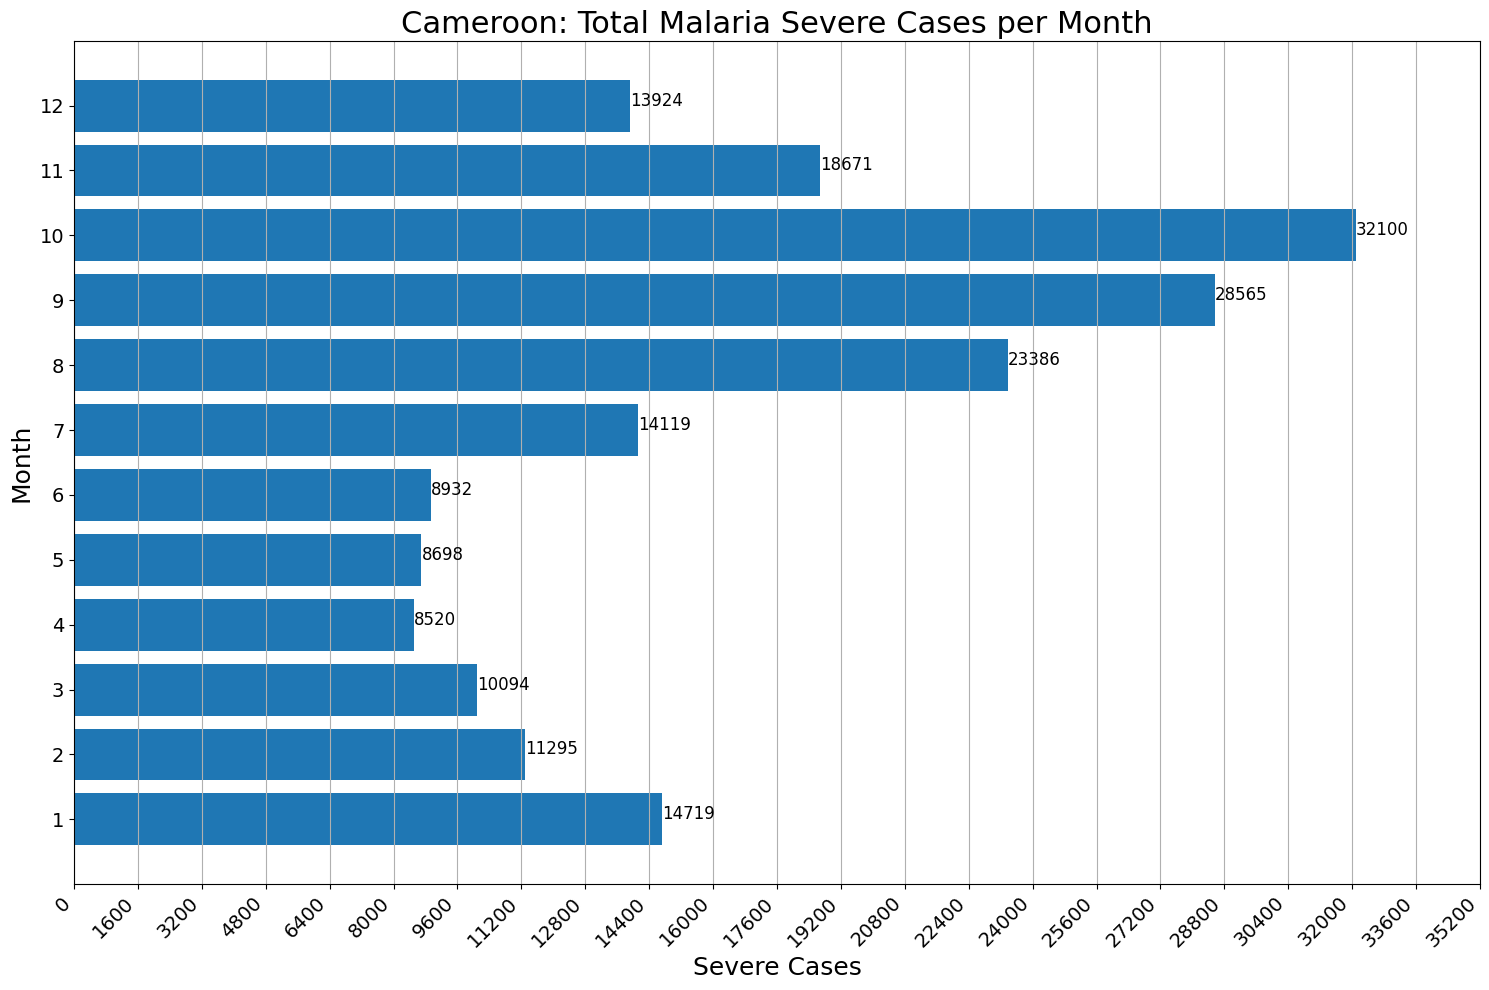

In [56]:
plot_grouped_barh(summed_data, group_col='Month', value_col='Sevr_TOTAL',
                  xlabel='Severe Cases', ylabel='Month', title='Cameroon: Total Malaria Severe Cases per Month')

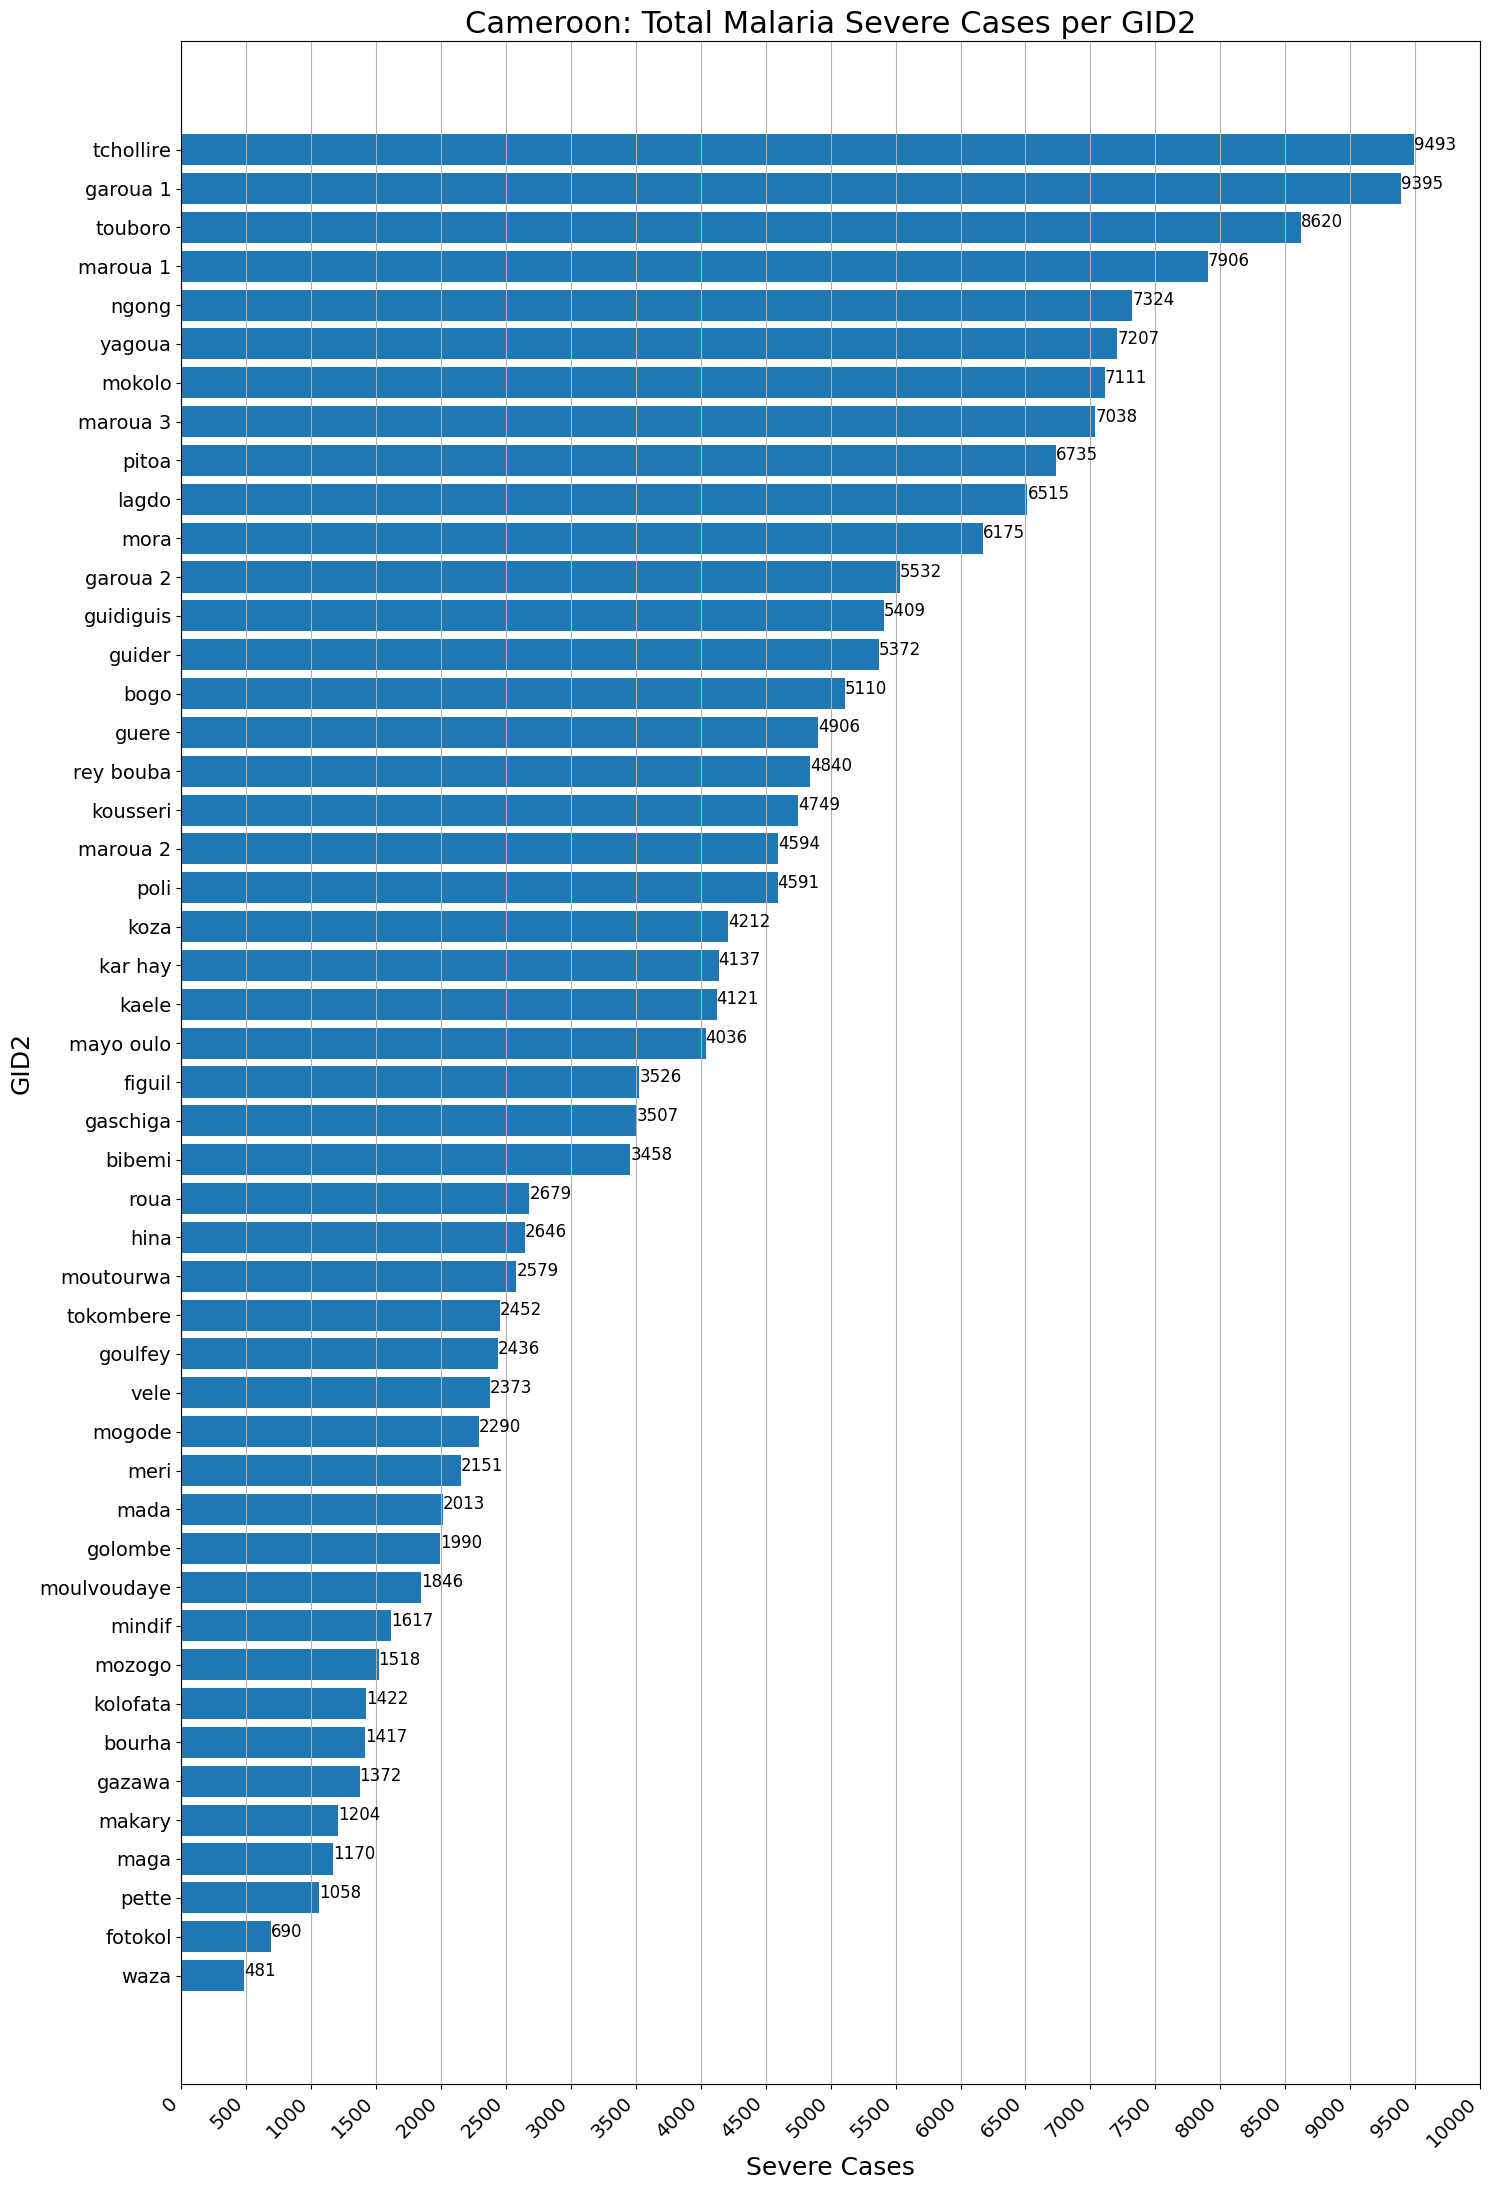

In [57]:
plot_grouped_barh(summed_data, group_col='GID2', value_col='Sevr_TOTAL',
                  xlabel='Severe Cases', ylabel='GID2', title='Cameroon: Total Malaria Severe Cases per GID2',
                  figsize=(15,22), text_size=12)

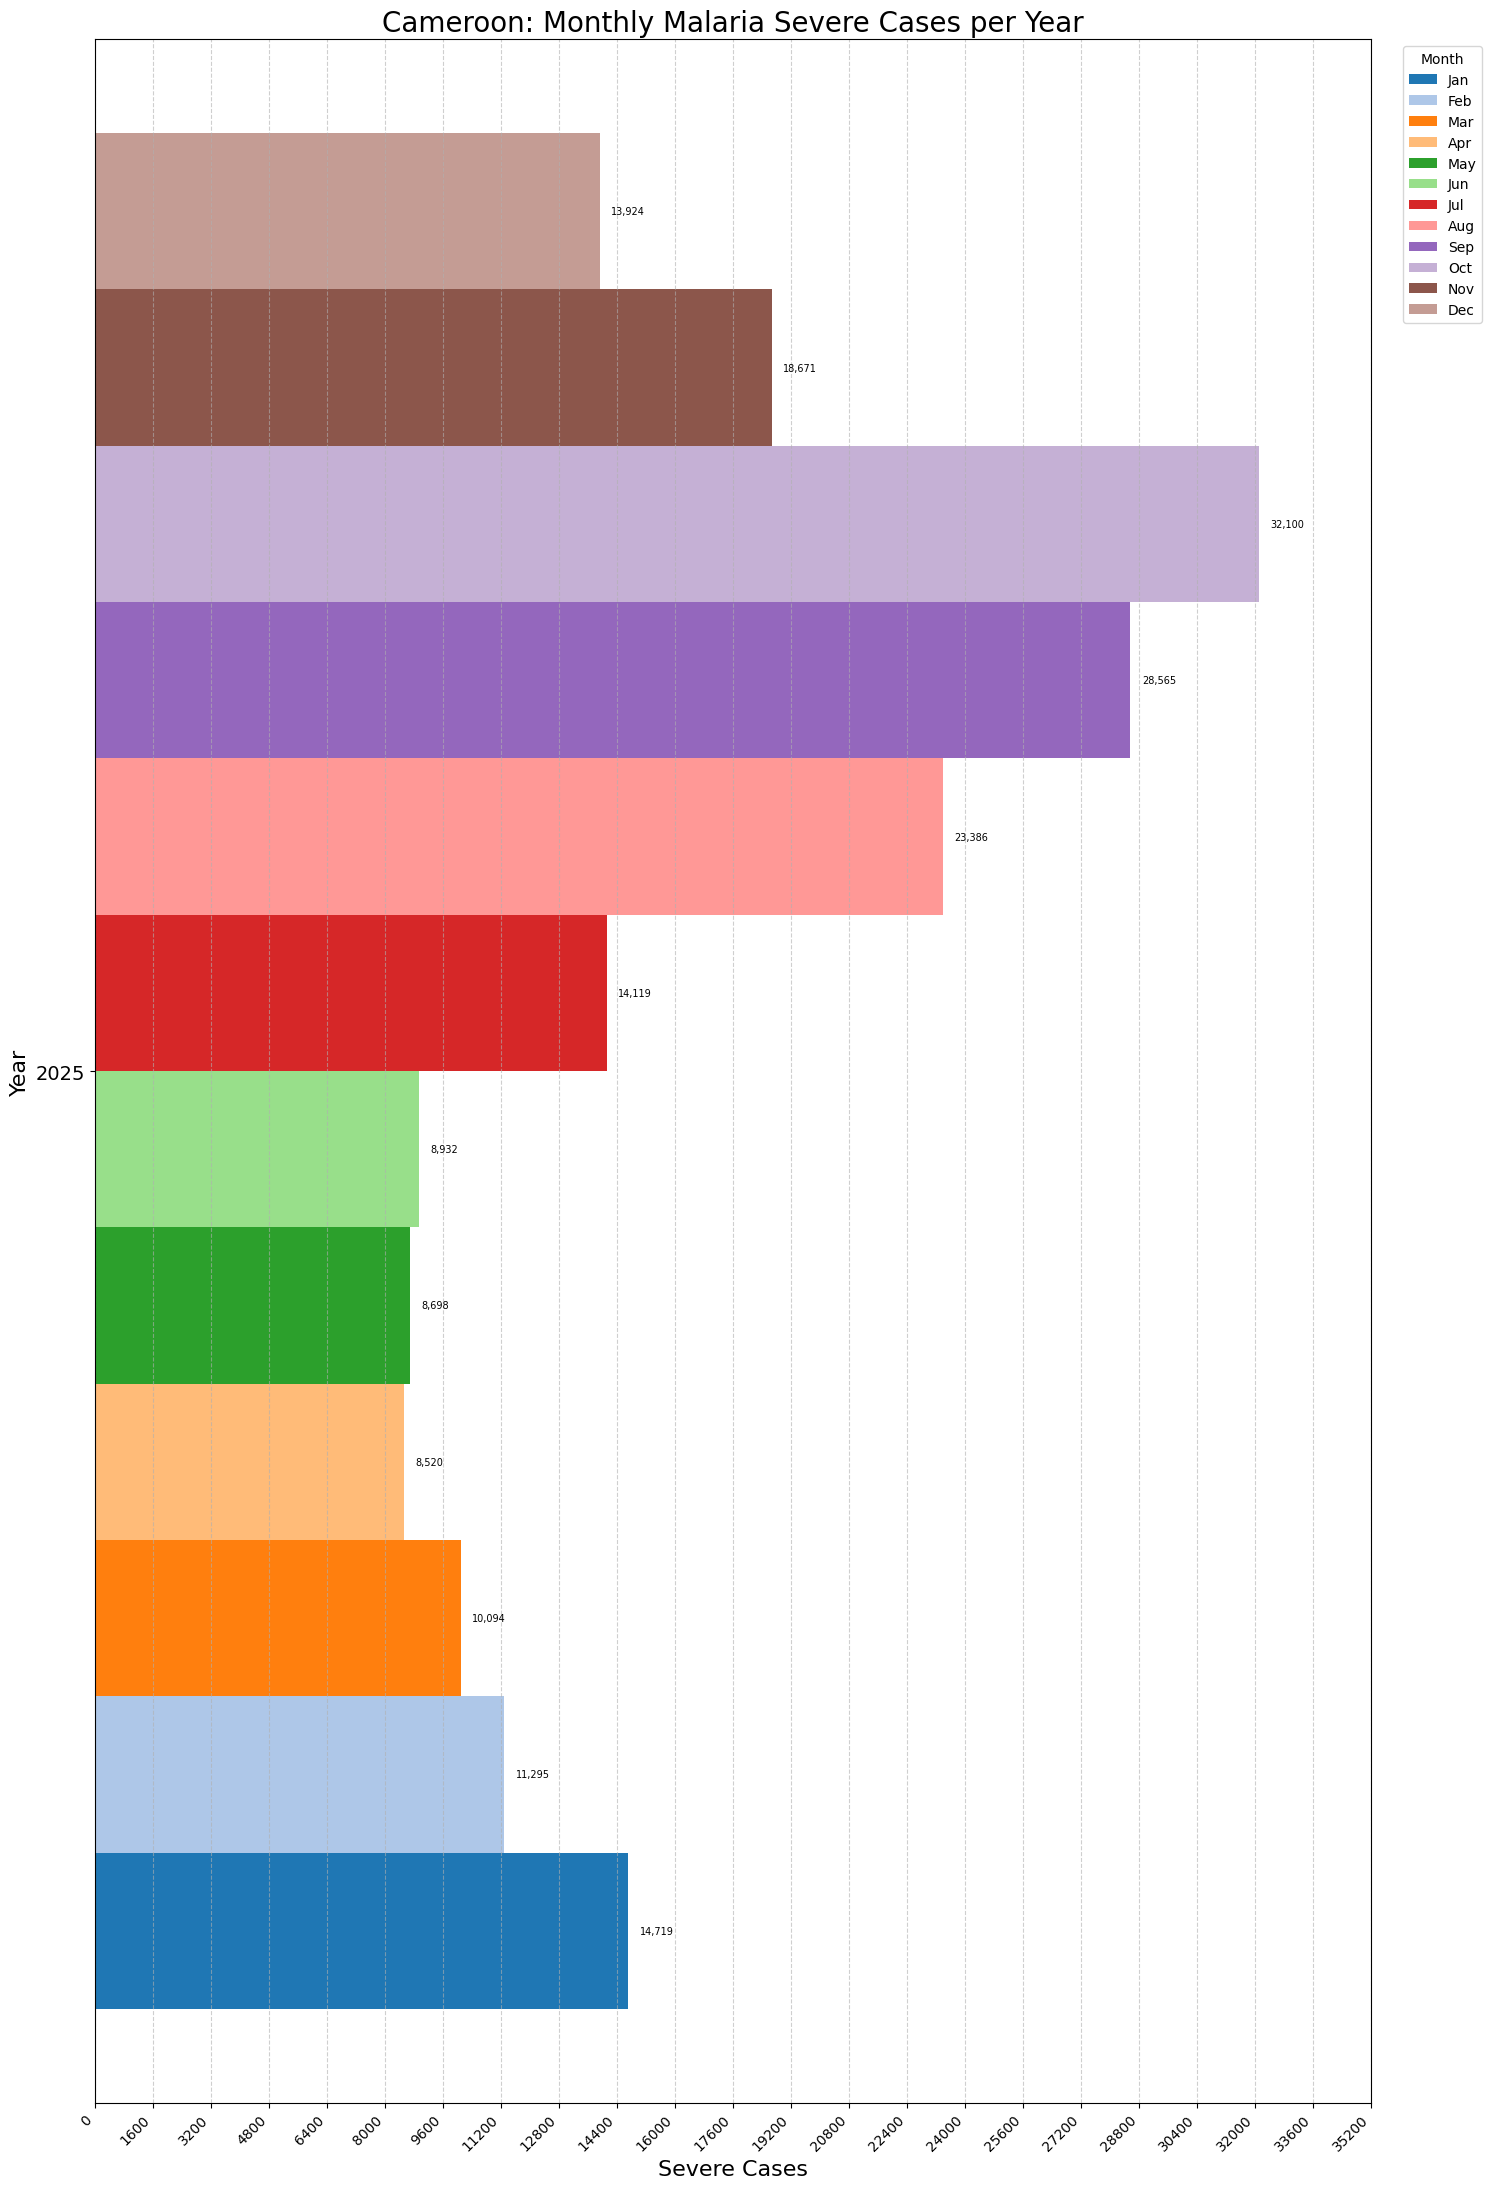

In [58]:
plot_monthly_yearly_horizontal_bars(summed_data, 'Sevr_TOTAL', bar_height_scale = 1.5, spacing_factor = 1.65, figsize=(15, 22),
                                    title='Cameroon: Monthly Malaria Severe Cases per Year', xlabel='Severe Cases')

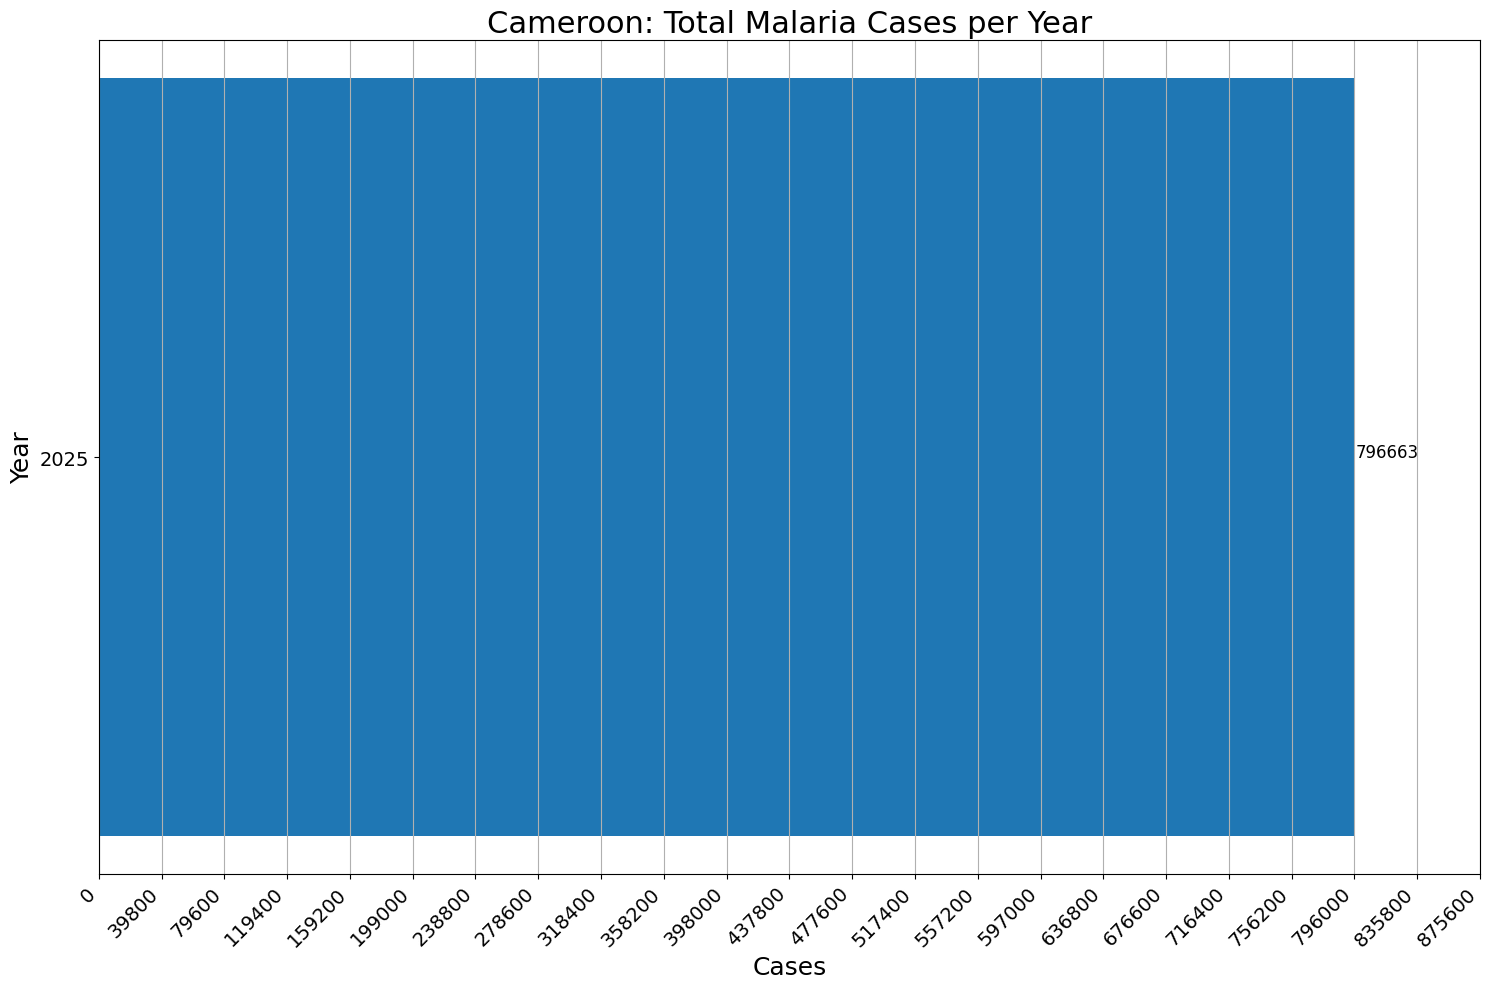

In [63]:
plot_grouped_barh(summed_data, group_col='Year', value_col='Case_TOTAL',
                          xlabel='Cases', ylabel='Year', title='Cameroon: Total Malaria Cases per Year')

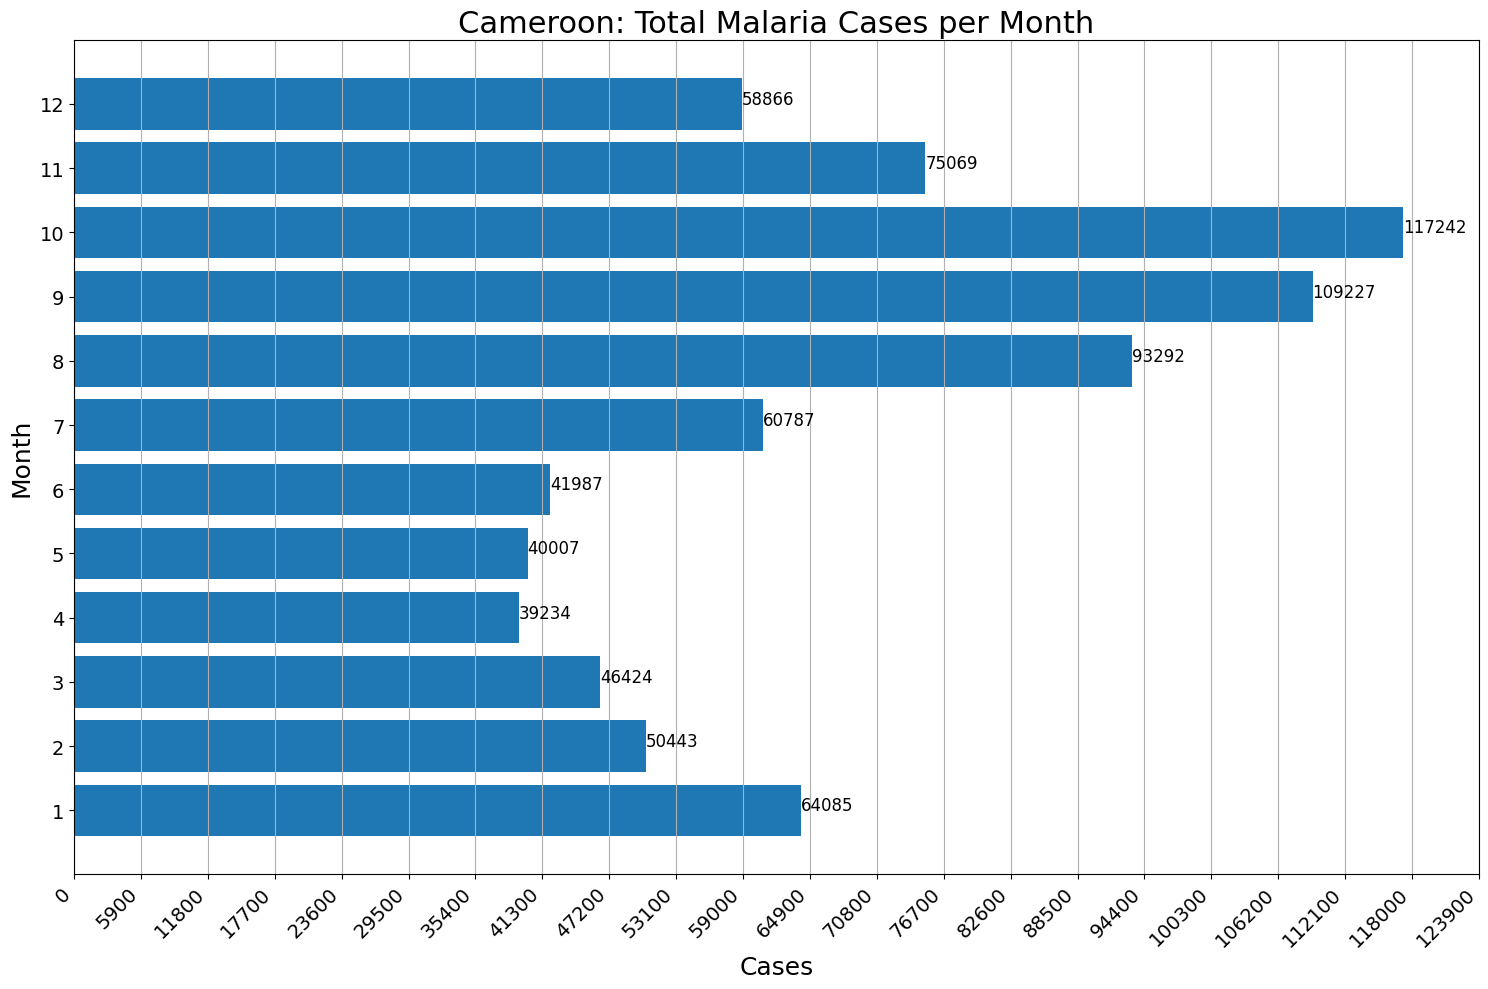

In [64]:
plot_grouped_barh(summed_data, group_col='Month', value_col='Case_TOTAL',
                          xlabel='Cases', ylabel='Month', title='Cameroon: Total Malaria Cases per Month')

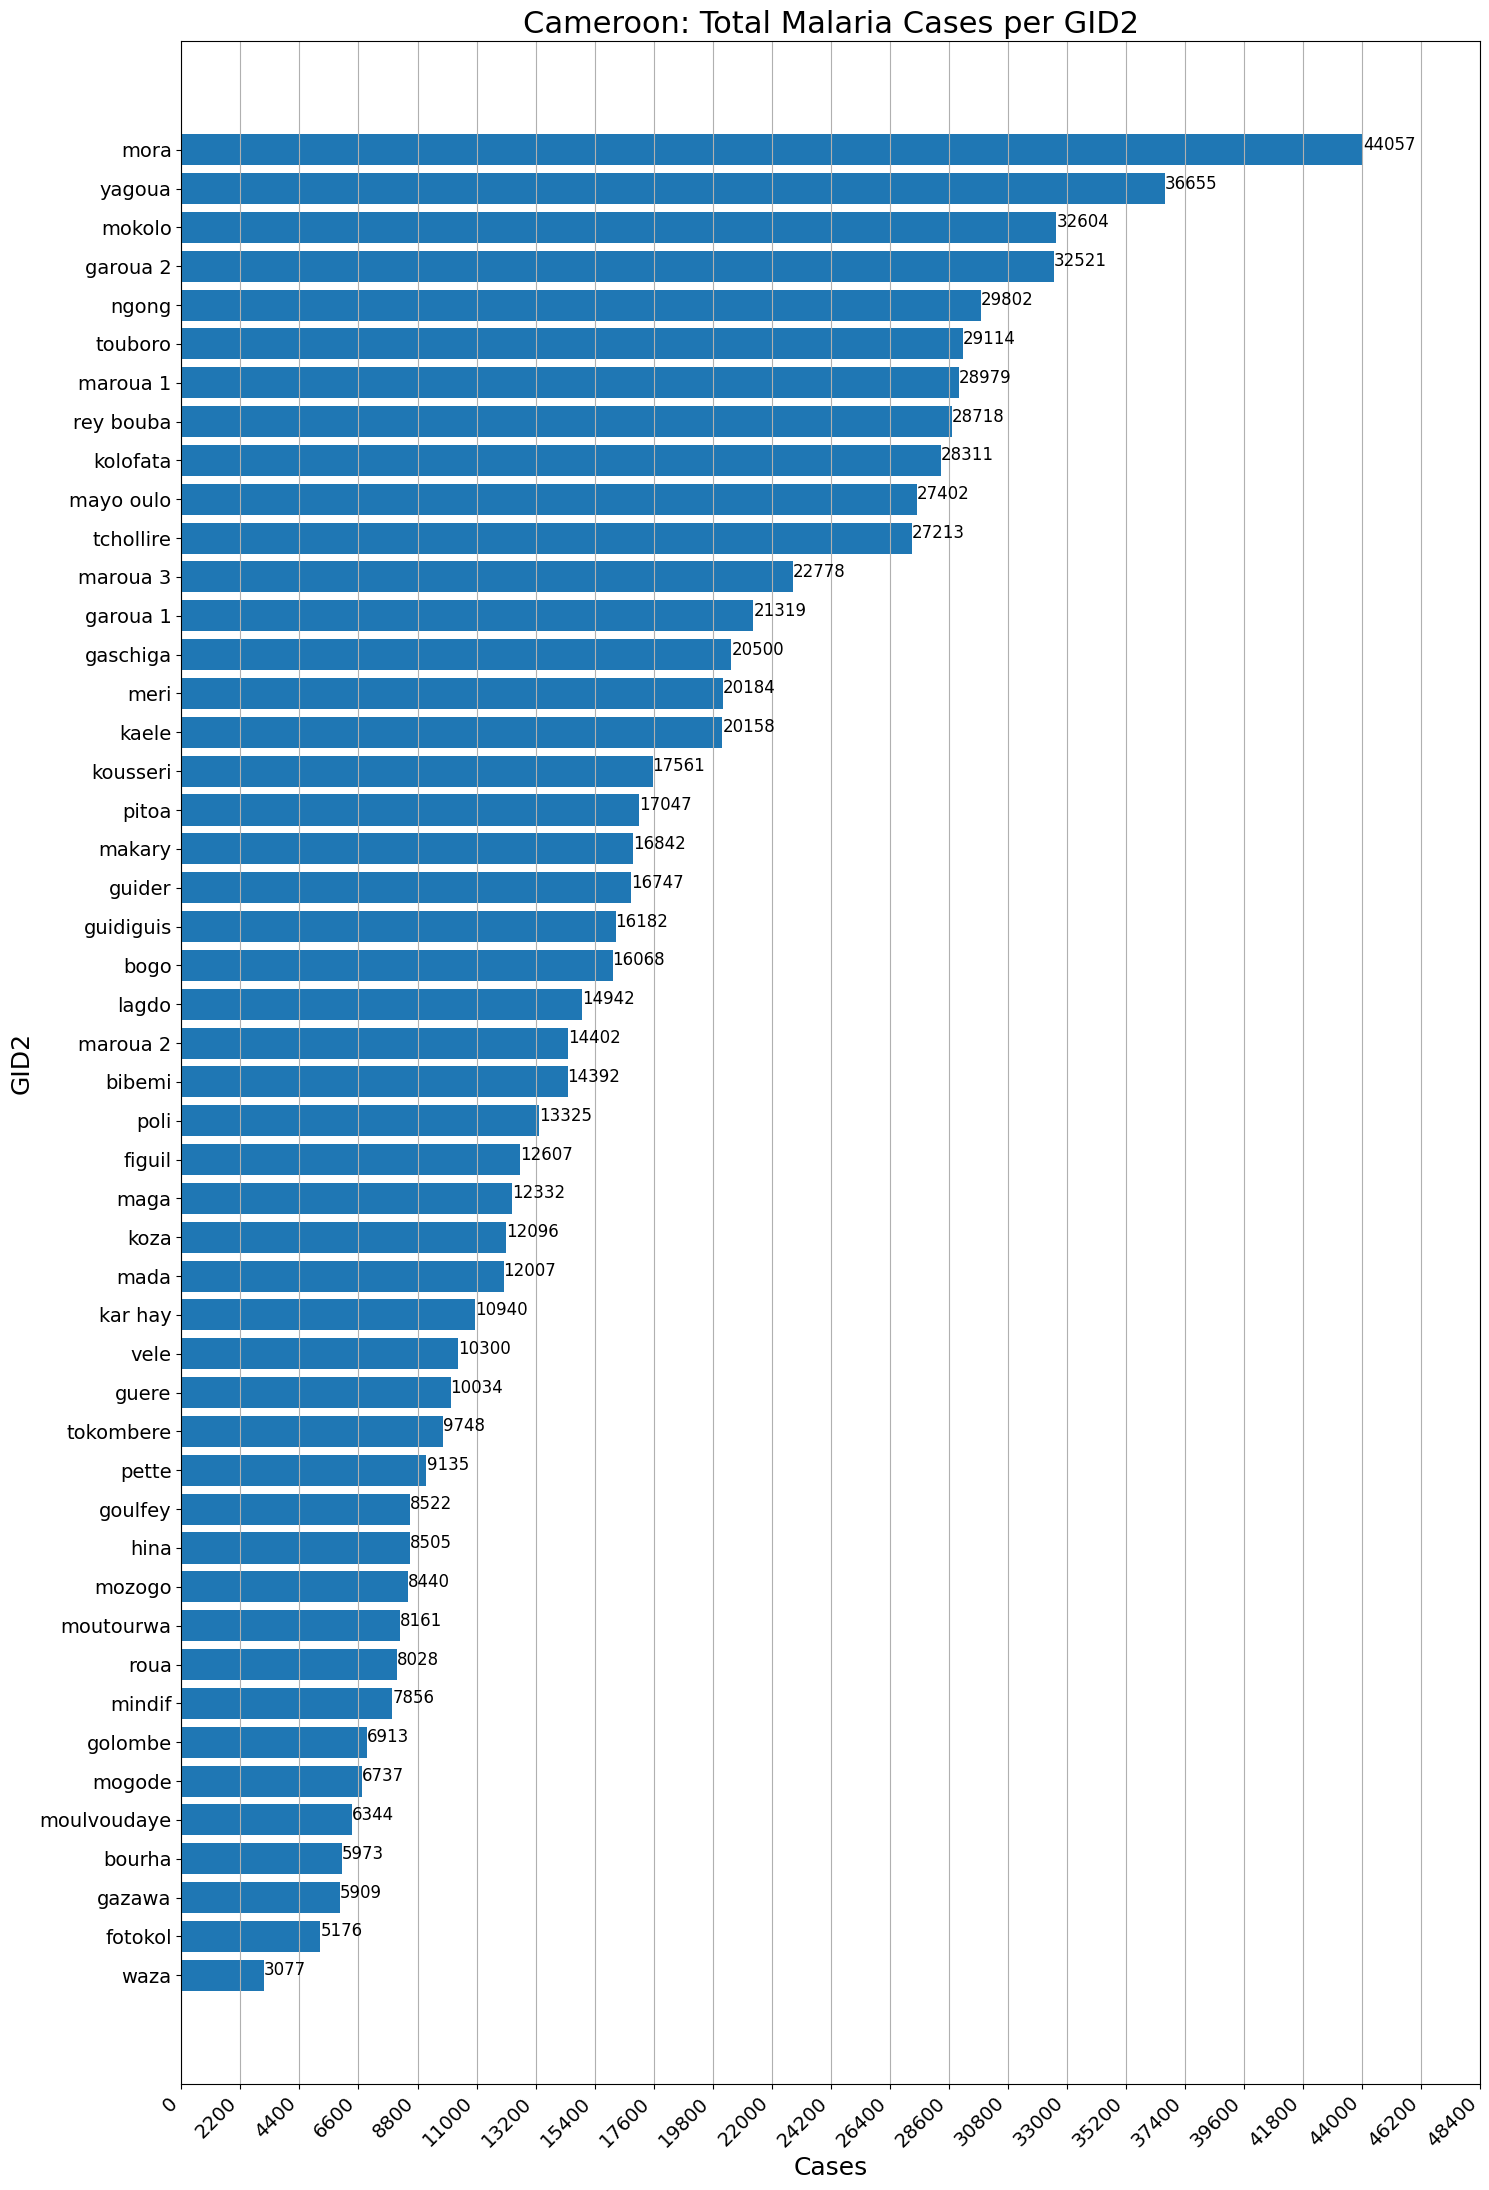

In [65]:
plot_grouped_barh(summed_data, group_col='GID2', value_col='Case_TOTAL',
                           xlabel='Cases', ylabel='GID2', title='Cameroon: Total Malaria Cases per GID2',
                           figsize=(15,22), text_size=12)

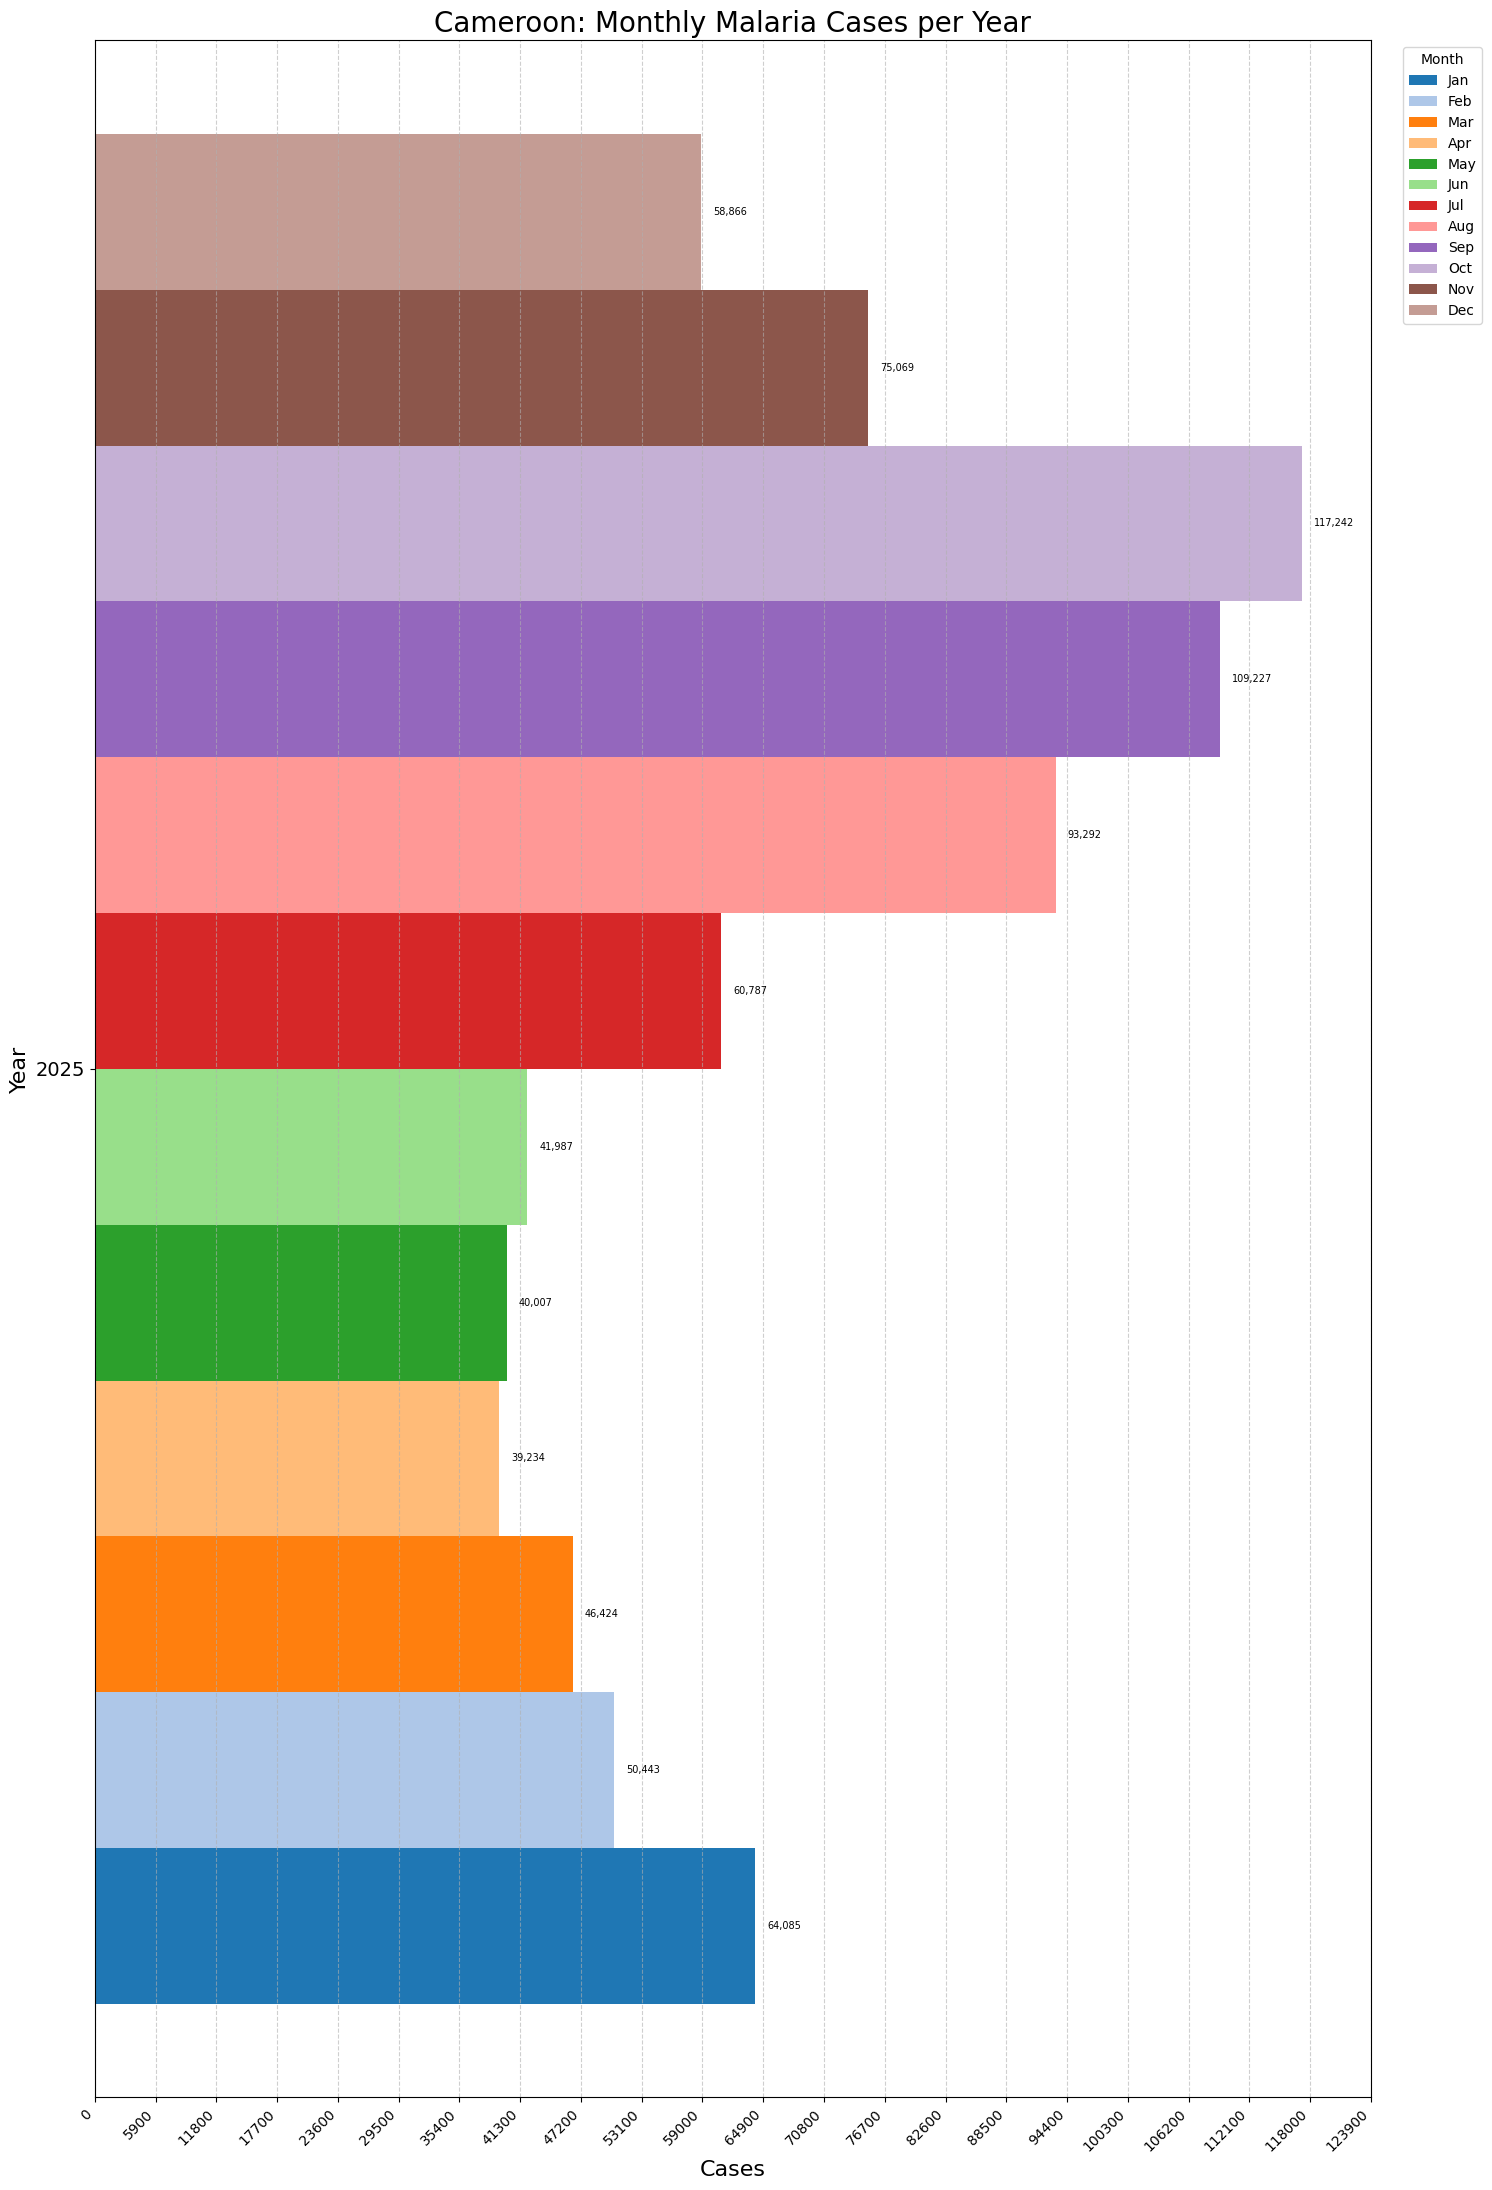

In [66]:
plot_monthly_yearly_horizontal_bars(summed_data, 'Case_TOTAL', bar_height_scale = 1.5, spacing_factor = 1.65, figsize=(15, 22), cmap='tab20',
                                    title='Cameroon: Monthly Malaria Cases per Year', xlabel='Cases')